-------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
from matplotlib import rc

system = platform.system()
if system == 'Darwin':  
    rc('font', family='AppleGothic') # 한국어 깨짐 방지용


plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지용

In [2]:
act = pd.read_csv("/Users/t2023-m0044/Downloads/라이프로그_병합파일_JY_ver_0/total_act.csv")
mmse = pd.read_csv("/Users/t2023-m0044/Downloads/라이프로그_병합파일_JY_ver_0/total_mmse.csv")
sleep = pd.read_csv("/Users/t2023-m0044/Downloads/라이프로그_병합파일_JY_ver_0/total_slp.csv")

---

# 전처리

1. 날짜형 컬럼 가시성 있게 변환

In [5]:
sleep.columns

Index(['EMAIL', 'sleep_awake', 'sleep_bedtime_end', 'sleep_bedtime_start',
       'sleep_breath_average', 'sleep_deep', 'sleep_duration',
       'sleep_efficiency', 'sleep_hr_5min', 'sleep_hr_average',
       'sleep_hr_lowest', 'sleep_hypnogram_5min', 'sleep_is_longest',
       'sleep_light', 'sleep_midpoint_at_delta', 'sleep_midpoint_time',
       'sleep_onset_latency', 'sleep_period_id', 'sleep_rem', 'sleep_restless',
       'sleep_rmssd', 'sleep_rmssd_5min', 'sleep_score',
       'sleep_score_alignment', 'sleep_score_deep', 'sleep_score_disturbances',
       'sleep_score_efficiency', 'sleep_score_latency', 'sleep_score_rem',
       'sleep_score_total', 'sleep_temperature_delta',
       'sleep_temperature_deviation', 'sleep_total',
       'CONVERT(sleep_hr_5min USING utf8)',
       'CONVERT(sleep_hypnogram_5min USING utf8)',
       'CONVERT(sleep_rmssd_5min USING utf8)', 'DIAG_NM'],
      dtype='object')

----

3. sleep CONVERT 열 처리하고 삭제

In [23]:


sleep.columns

Index(['EMAIL', 'sleep_awake', 'sleep_bedtime_end', 'sleep_bedtime_start',
       'sleep_breath_average', 'sleep_deep', 'sleep_duration',
       'sleep_efficiency', 'sleep_hr_5min', 'sleep_hr_average',
       'sleep_hr_lowest', 'sleep_hypnogram_5min', 'sleep_is_longest',
       'sleep_light', 'sleep_midpoint_at_delta', 'sleep_midpoint_time',
       'sleep_onset_latency', 'sleep_period_id', 'sleep_rem', 'sleep_restless',
       'sleep_rmssd', 'sleep_rmssd_5min', 'sleep_score',
       'sleep_score_alignment', 'sleep_score_deep', 'sleep_score_disturbances',
       'sleep_score_efficiency', 'sleep_score_latency', 'sleep_score_rem',
       'sleep_score_total', 'sleep_temperature_delta',
       'sleep_temperature_deviation', 'sleep_total',
       'CONVERT(sleep_hr_5min USING utf8)',
       'CONVERT(sleep_hypnogram_5min USING utf8)',
       'CONVERT(sleep_rmssd_5min USING utf8)', 'DIAG_NM'],
      dtype='object')

In [24]:
sleep['sleep_hr_5min']

0        ...
1        ...
2        ...
3        ...
4        ...
        ... 
12178    ...
12179    ...
12180    ...
12181    ...
12182    ...
Name: sleep_hr_5min, Length: 12183, dtype: object

In [25]:

sleep['sleep_hr_5min'].unique()

array(['...'], dtype=object)

-> 빈 컬럼 확인

In [26]:
sleep['5_count'] = sleep['CONVERT(sleep_hr_5min USING utf8)'].apply(lambda x: len(str(x).split('/')))
sleep['5_count'].value_counts().reset_index()

,5_count,count
0,95,256
1,97,245
2,98,242
3,102,239
4,96,239
...,...,...
138,180,2
139,181,2
140,41,1
141,179,1


In [27]:
sleep['sleep_hr_5min'] = sleep['CONVERT(sleep_hr_5min USING utf8)'].apply(
    lambda x: [float(i) for i in x.split('/') if i.strip() not in ['', None]] if isinstance(x, str) else []
)

In [28]:
sleep['sleep_hr_5min']

0        [63.0, 61.0, 59.0, 58.0, 58.0, 58.0, 56.0, 55....
1        [0.0, 51.0, 0.0, 51.0, 52.0, 52.0, 52.0, 52.0,...
2        [54.0, 56.0, 0.0, 55.0, 53.0, 55.0, 56.0, 55.0...
3        [0.0, 54.0, 53.0, 53.0, 54.0, 54.0, 54.0, 53.0...
4        [0.0, 49.0, 50.0, 50.0, 50.0, 50.0, 50.0, 50.0...
                               ...                        
12178    [66.0, 66.0, 65.0, 64.0, 65.0, 65.0, 65.0, 63....
12179    [66.0, 0.0, 0.0, 69.0, 69.0, 69.0, 67.0, 65.0,...
12180    [63.0, 63.0, 63.0, 62.0, 63.0, 62.0, 62.0, 62....
12181    [0.0, 72.0, 71.0, 70.0, 68.0, 69.0, 69.0, 68.0...
12182    [0.0, 0.0, 0.0, 0.0, 64.0, 66.0, 66.0, 65.0, 6...
Name: sleep_hr_5min, Length: 12183, dtype: object


-> 5분 수면 심박수 처리 완료

In [29]:
sleep['sleep_hypnogram_5min']

0        ...
1        ...
2        ...
3        ...
4        ...
        ... 
12178    ...
12179    ...
12180    ...
12181    ...
12182    ...
Name: sleep_hypnogram_5min, Length: 12183, dtype: object

In [30]:
sleep['sleep_hypnogram_5min'].unique()

array(['...'], dtype=object)

-> 빈 배열 확인

In [31]:
sleep['5h_count'] = sleep['CONVERT(sleep_hypnogram_5min USING utf8)'].apply(lambda x: len(str(x).split('/')))
sleep['5h_count'].value_counts().reset_index()

,5h_count,count
0,95,249
1,99,245
2,96,243
3,103,240
4,102,240
...,...,...
137,173,3
138,41,2
139,180,2
140,38,1


In [32]:
sleep['sleep_hypnogram_5min'] = sleep['CONVERT(sleep_hypnogram_5min USING utf8)'].apply(
    lambda x: [float(i) for i in x.split('/') if i.strip() not in ['', None]] if isinstance(x, str) else []
)

In [33]:
sleep['sleep_hypnogram_5min']

0        [4.0, 2.0, 2.0, 2.0, 2.0, 1.0, 1.0, 2.0, 2.0, ...
1        [4.0, 2.0, 4.0, 2.0, 2.0, 2.0, 1.0, 1.0, 1.0, ...
2        [4.0, 2.0, 1.0, 1.0, 2.0, 2.0, 4.0, 4.0, 4.0, ...
3        [4.0, 4.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...
4        [4.0, 2.0, 2.0, 2.0, 2.0, 1.0, 1.0, 1.0, 2.0, ...
                               ...                        
12178    [4.0, 2.0, 4.0, 4.0, 2.0, 2.0, 2.0, 2.0, 3.0, ...
12179    [4.0, 2.0, 4.0, 2.0, 1.0, 4.0, 2.0, 2.0, 2.0, ...
12180    [4.0, 2.0, 2.0, 2.0, 2.0, 2.0, 1.0, 1.0, 1.0, ...
12181    [4.0, 2.0, 2.0, 4.0, 4.0, 2.0, 1.0, 1.0, 4.0, ...
12182    [4.0, 4.0, 4.0, 4.0, 2.0, 2.0, 2.0, 1.0, 1.0, ...
Name: sleep_hypnogram_5min, Length: 12183, dtype: object

-> 5분 수면 상태 처리 완료

In [34]:
sleep['sleep_rmssd_5min']

0        ...
1        ...
2        ...
3        ...
4        ...
        ... 
12178    ...
12179    ...
12180    ...
12181    ...
12182    ...
Name: sleep_rmssd_5min, Length: 12183, dtype: object

In [35]:
sleep['sleep_rmssd_5min'].unique()

array(['...'], dtype=object)

-> 빈 배열 확인

In [36]:
sleep['5r_count'] = sleep['CONVERT(sleep_rmssd_5min USING utf8)'].apply(lambda x: len(str(x).split('/')))
sleep['5r_count'].value_counts().reset_index()

,5r_count,count
0,95,256
1,97,245
2,98,242
3,102,239
4,96,239
...,...,...
138,180,2
139,181,2
140,41,1
141,179,1


In [37]:
sleep['sleep_rmssd_5min'] = sleep['CONVERT(sleep_rmssd_5min USING utf8)'].apply(
    lambda x: [float(i) for i in x.split('/') if i.strip() not in ['', None]] if isinstance(x, str) else []
)

In [38]:
sleep['sleep_rmssd_5min']

0        [18.0, 28.0, 25.0, 28.0, 34.0, 34.0, 35.0, 45....
1        [0.0, 49.0, 0.0, 38.0, 51.0, 17.0, 18.0, 18.0,...
2        [56.0, 47.0, 0.0, 49.0, 42.0, 57.0, 44.0, 49.0...
3        [0.0, 40.0, 40.0, 40.0, 37.0, 46.0, 35.0, 46.0...
4        [0.0, 81.0, 60.0, 74.0, 62.0, 63.0, 56.0, 78.0...
                               ...                        
12178    [45.0, 35.0, 29.0, 27.0, 34.0, 30.0, 31.0, 32....
12179    [21.0, 0.0, 0.0, 30.0, 31.0, 35.0, 35.0, 29.0,...
12180    [29.0, 28.0, 28.0, 32.0, 27.0, 35.0, 34.0, 36....
12181    [0.0, 19.0, 14.0, 14.0, 22.0, 20.0, 22.0, 22.0...
12182    [0.0, 0.0, 0.0, 0.0, 25.0, 31.0, 33.0, 35.0, 3...
Name: sleep_rmssd_5min, Length: 12183, dtype: object

-> 5분 수면 심박변동 처리 완료

In [39]:
sleep.drop(columns=['CONVERT(sleep_hypnogram_5min USING utf8)', 'CONVERT(sleep_rmssd_5min USING utf8)','CONVERT(sleep_hypnogram_5min USING utf8)', '5_count', '5h_count', '5r_count'], inplace = True)

In [40]:
dict = {
    'email': '이메일',
    'activity_average_met': '하루 평균 운동 강도',
    'activity_cal_active': '하루간 활동 칼로리',
    'activity_cal_total': '하루간 총 사용 칼로리',
    'activity_class_5min': '하루간 5분당 활동 로그',
    'activity_daily_movement': '하루동안 움직인 거리',
    'activity_day_end': '활동 종료 시간',
    'activity_day_start': '활동 시작 시간',
    'activity_high': '고강도 활동 시간',
    'activity_inactive': '비활동 시간',
    'activity_inactivity_alerts': '비활동 알람 횟수',
    'activity_low': '저강도 활동 시간',
    'activity_medium': '중강도 활동 시간',
    'activity_met_1min': '하루간 분당 운동 강도 로그',
    'activity_met_min_high': '하루간 고강도 운동 강도',
    'activity_met_min_inactive': '하루간 비활동 운동 강도',
    'activity_met_min_low': '하루간 저강도 활동 운동 강도',
    'activity_met_min_medium': '하루간 중강도 활동 운동 강도',
    'activity_non_wear': '미착용 시간',
    'activity_rest': '휴식 시간',
    'activity_score': '활동 점수',
    'activity_score_meet_daily_targets': '활동 목표달성 점수',
    'activity_score_move_every_hour': '매 시간 당 활동유지 점수',
    'activity_score_recovery_time': '회복시간 점수',
    'activity_score_stay_active': '활동 유지 점수',
    'activity_score_training_frequency': '운동 빈도 점수',
    'activity_score_training_volume': '운동량 점수',
    'activity_steps': '매일 걸음 수',
    'activity_total': '활동 총 시간',
    'DIAG_NM' : '진단'
}

act = act.rename(columns= dict)

In [41]:
act['진단'] = act['진단'].apply(lambda x: '정상' if x == 'CN' else '치매')

----

SLEEP

In [42]:
sleep.columns

Index(['EMAIL', 'sleep_awake', 'sleep_bedtime_end', 'sleep_bedtime_start',
       'sleep_breath_average', 'sleep_deep', 'sleep_duration',
       'sleep_efficiency', 'sleep_hr_5min', 'sleep_hr_average',
       'sleep_hr_lowest', 'sleep_hypnogram_5min', 'sleep_is_longest',
       'sleep_light', 'sleep_midpoint_at_delta', 'sleep_midpoint_time',
       'sleep_onset_latency', 'sleep_period_id', 'sleep_rem', 'sleep_restless',
       'sleep_rmssd', 'sleep_rmssd_5min', 'sleep_score',
       'sleep_score_alignment', 'sleep_score_deep', 'sleep_score_disturbances',
       'sleep_score_efficiency', 'sleep_score_latency', 'sleep_score_rem',
       'sleep_score_total', 'sleep_temperature_delta',
       'sleep_temperature_deviation', 'sleep_total',
       'CONVERT(sleep_hr_5min USING utf8)', 'DIAG_NM'],
      dtype='object')

In [43]:
sleep.drop(columns=[
    'CONVERT(sleep_hr_5min USING utf8)',
    'sleep_period_id'
], inplace=True)

In [44]:
sleep.rename(columns={
    'EMAIL': '이메일',
    'sleep_awake': '깬 시간',
    'sleep_bedtime_end': '잠 종료 시간',
    'sleep_bedtime_start': '잠 시작 시간',
    'sleep_breath_average': '분당 평균 호흡 수',
    'sleep_deep': '깊은 수면 시간',
    'sleep_duration': '잠 시간',
    'sleep_efficiency': '수면 효율',
    'sleep_hr_5min': '5분 당 심박동 로그',
    'sleep_hr_average': '분당 평균 심박동 수',
    'sleep_hr_lowest': '분당 낮은 심박동 수',
    'sleep_hypnogram_5min': '수면 상태 로그',
    'sleep_is_longest': '본 수면 여부',
    'sleep_light': '가벼운 수면 시간',
    'sleep_midpoint_at_delta': '수면 중간점 시간 델타',
    'sleep_midpoint_time': '수면 중간점 시간',
    'sleep_onset_latency': '수면 잠복 시간',
    'sleep_rem': '램 수면 시간',
    'sleep_restless': '뒤척임 비율',
    'sleep_rmssd': '평균 심박동 변동',
    'sleep_rmssd_5min': '5분당 심박동 변동 로그',
    'sleep_score': '수면 종합 점수',
    'sleep_score_alignment': '수면 시기 점수',
    'sleep_score_deep': '깊은 수면 점수',
    'sleep_score_disturbances': '수면 방해 점수',
    'sleep_score_efficiency': '수면 효율 점수',
    'sleep_score_latency': '수면 잠복 점수',
    'sleep_score_rem': '램수면 점수',
    'sleep_score_total': '수면 점수 총합',
    'sleep_temperature_delta': '피부 온도 편차',
    'sleep_temperature_deviation': '피부 온도 경향 편차',
    'sleep_total': '수면 시간',
    'DIAG_NM': '진단'
}, inplace=True)

In [45]:
sleep['진단'] = sleep['진단'].apply(lambda x: '정상' if x == 'CN' else '치매')

In [46]:
sleep['이메일'].nunique()

174

In [47]:
sleep.describe()

,깬 시간,분당 평균 호흡 수,깊은 수면 시간,잠 시간,수면 효율,분당 평균 심박동 수,분당 낮은 심박동 수,본 수면 여부,가벼운 수면 시간,수면 중간점 시간 델타,...,수면 시기 점수,깊은 수면 점수,수면 방해 점수,수면 효율 점수,수면 잠복 점수,램수면 점수,수면 점수 총합,피부 온도 편차,피부 온도 경향 편차,수면 시간
count,12183.000000,12183.000000,12183.000000,12183.000000,12183.000000,12183.000000,12183.000000,12183.0,12183.000000,12183.00000,...,12183.000000,12183.000000,12183.000000,12183.000000,12183.000000,12183.000000,12183.000000,12183.000000,12183.000000,12183.000000
mean,5556.126570,16.762846,5120.891406,29240.334893,81.642863,60.459236,54.979233,1.0,14805.020931,11244.52565,...,90.902897,81.559550,65.733235,75.380448,79.552902,56.209801,71.988344,-0.009885,-0.009885,23684.208323
std,3454.987265,1.294468,2593.170965,6959.797118,8.759858,7.308937,6.603692,0.0,4403.484156,15622.85762,...,18.045520,24.893318,12.719209,19.297870,15.006138,29.531208,20.139679,0.315838,0.315838,5342.030174
min,510.000000,11.750000,0.000000,10800.000000,39.000000,35.900000,33.000000,1.0,1500.000000,-9212.00000,...,1.000000,1.000000,14.000000,8.000000,1.000000,1.000000,14.000000,-1.980000,-1.980000,5910.000000
25%,3060.000000,16.000000,3210.000000,24660.000000,76.000000,55.270000,50.000000,1.0,11670.000000,5223.00000,...,90.000000,70.000000,56.000000,65.000000,70.000000,31.000000,58.000000,-0.180000,-0.180000,20130.000000
50%,4740.000000,16.875000,4950.000000,29040.000000,83.000000,60.120000,55.000000,1.0,14580.000000,8429.00000,...,100.000000,96.000000,67.000000,79.000000,81.000000,56.000000,74.000000,0.000000,0.000000,23880.000000
75%,7200.000000,17.625000,6780.000000,33480.000000,88.000000,65.145000,59.000000,1.0,17610.000000,11909.00000,...,100.000000,98.000000,75.000000,90.000000,91.000000,83.000000,89.000000,0.160000,0.160000,27150.000000
max,27420.000000,22.250000,15390.000000,54000.000000,98.000000,99.990000,91.000000,1.0,38190.000000,98539.00000,...,100.000000,100.000000,99.000000,100.000000,99.000000,100.000000,100.000000,3.140000,3.140000,47790.000000


In [48]:
sleep.head(1)

,이메일,깬 시간,잠 종료 시간,잠 시작 시간,분당 평균 호흡 수,깊은 수면 시간,잠 시간,수면 효율,5분 당 심박동 로그,분당 평균 심박동 수,...,깊은 수면 점수,수면 방해 점수,수면 효율 점수,수면 잠복 점수,램수면 점수,수면 점수 총합,피부 온도 편차,피부 온도 경향 편차,수면 시간,진단
0,nia+279@rowan.kr,8700,2020-10-19 05:10:28,2020-10-18 18:38:28,17.875,10110,37920,77,"[63.0, 61.0, 59.0, 58.0, 58.0, 58.0, 56.0, 55....",53.04,...,100,78,65,89,56,94,0.0,0.0,29220,치매


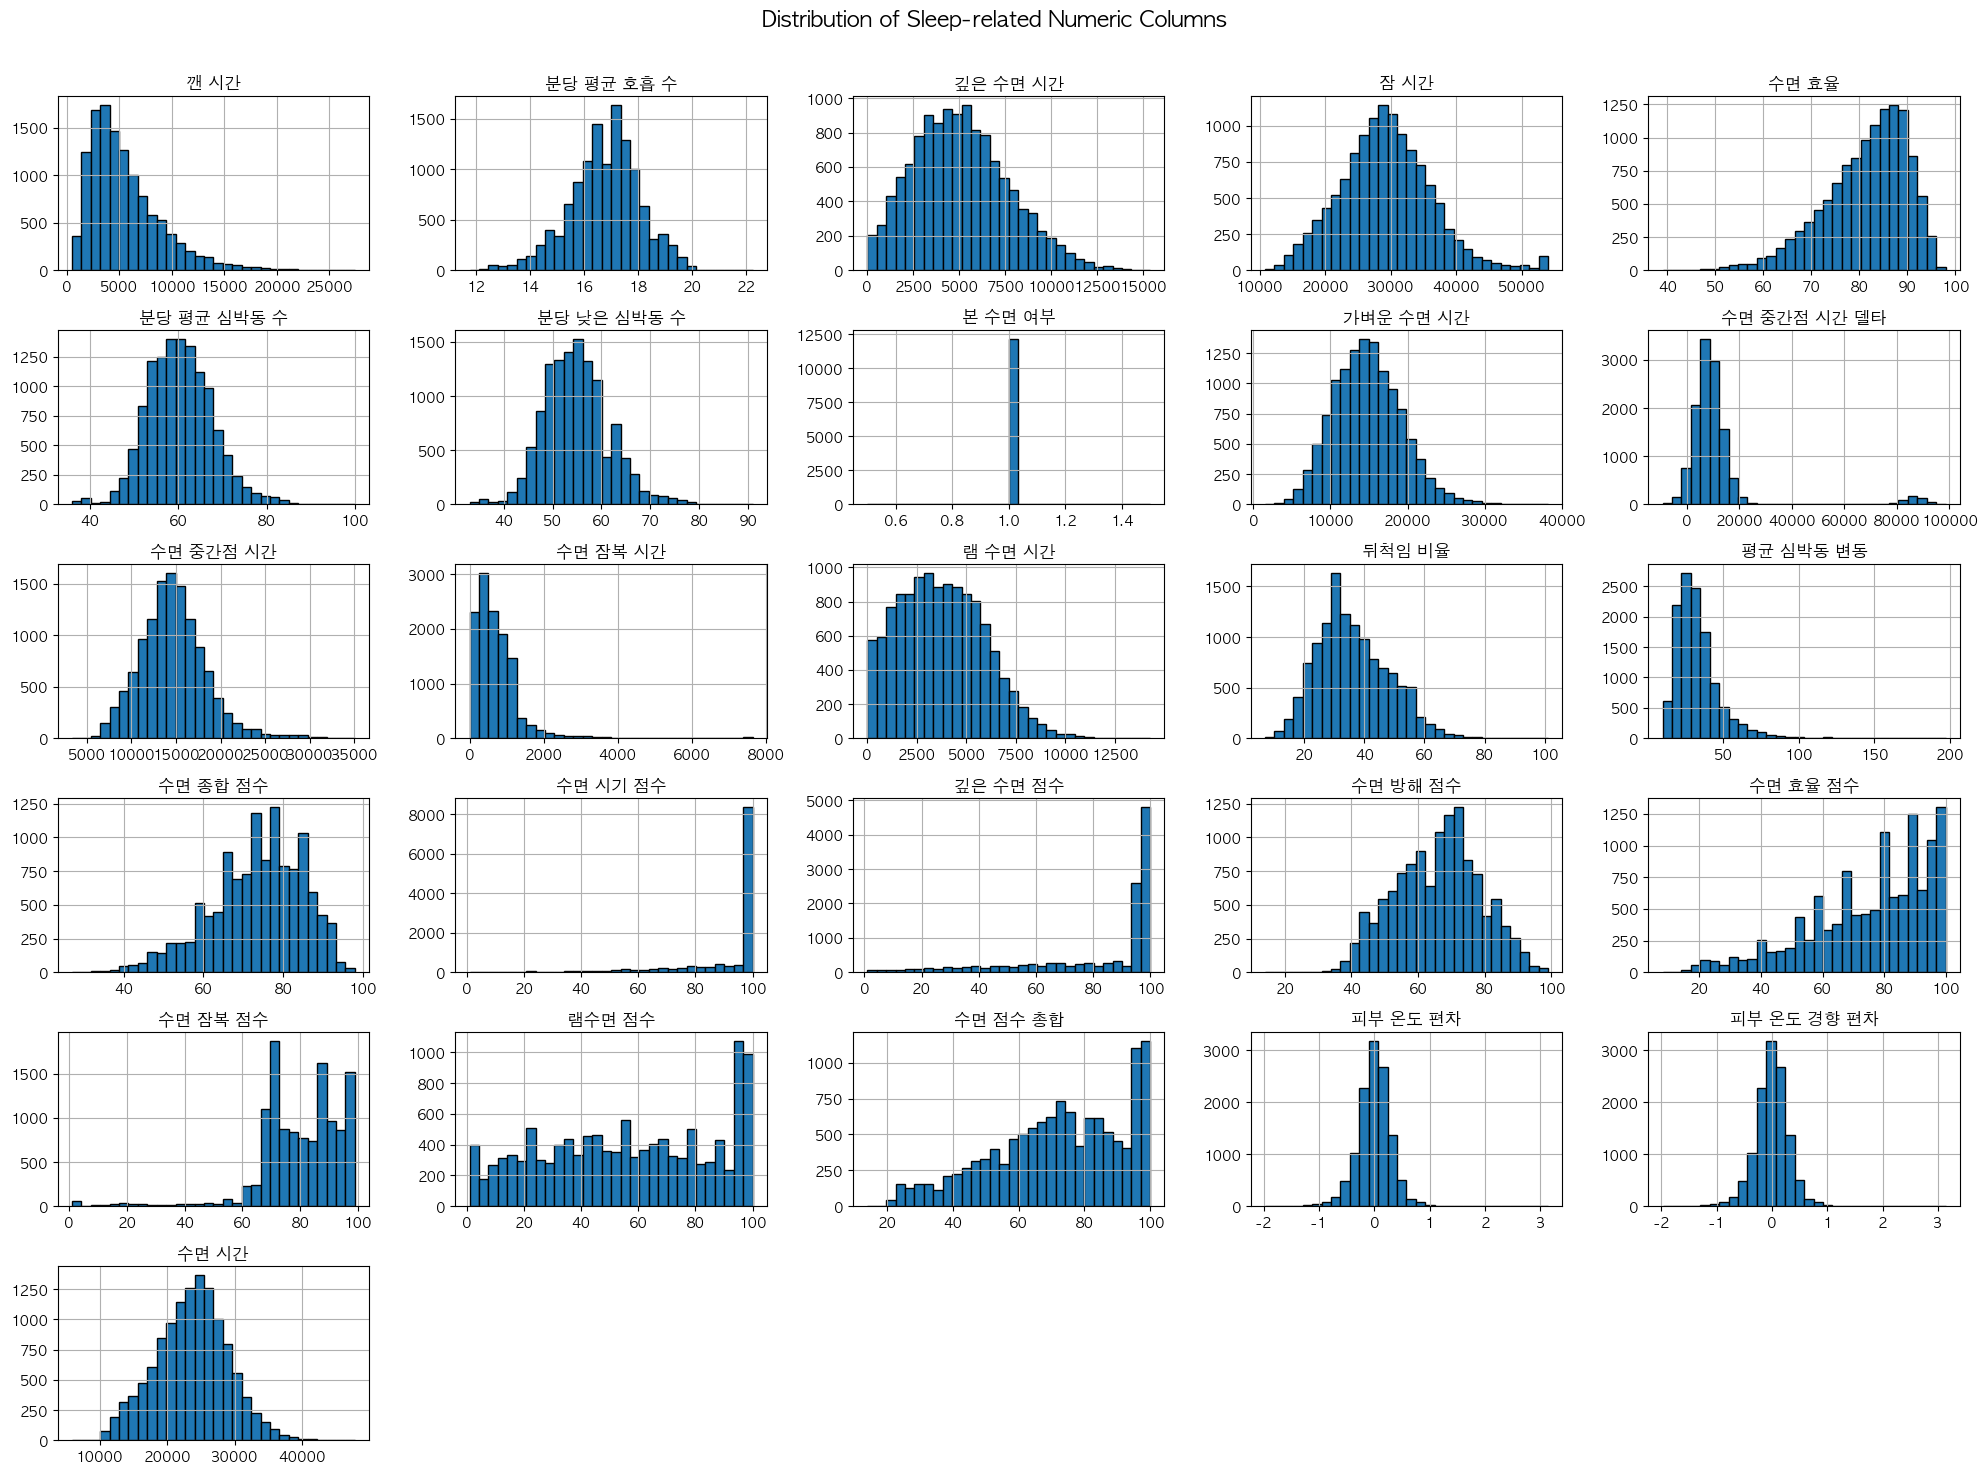

In [49]:
# sleep 관련 주요 수치형 컬럼만 추출
sleep_numeric = sleep.select_dtypes(include=['number'])

# 히스토그램 시각화
sleep_numeric.hist(figsize=(20, 15), bins=30, grid=True, edgecolor='black')
plt.suptitle("Distribution of Sleep-related Numeric Columns", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [50]:
sleep_numeric.head(10)

,깬 시간,분당 평균 호흡 수,깊은 수면 시간,잠 시간,수면 효율,분당 평균 심박동 수,분당 낮은 심박동 수,본 수면 여부,가벼운 수면 시간,수면 중간점 시간 델타,...,수면 시기 점수,깊은 수면 점수,수면 방해 점수,수면 효율 점수,수면 잠복 점수,램수면 점수,수면 점수 총합,피부 온도 편차,피부 온도 경향 편차,수면 시간
0,8700,17.875,10110,37920,77,53.04,49,1,15330,84928,...,87,100,78,65,89,56,94,0.00,0.00,29220
1,6570,18.000,7440,28680,77,52.82,49,1,11820,4582,...,100,98,77,65,97,43,65,0.34,0.34,22110
2,10530,18.000,4620,32040,67,52.01,47,1,12360,7078,...,100,94,60,41,75,68,62,-0.07,-0.07,21510
3,4080,17.500,7440,25440,84,51.07,46,1,9060,5776,...,100,98,80,81,83,73,62,-0.14,-0.14,21360
4,7170,17.875,4320,20700,65,50.80,47,1,7470,-2220,...,80,88,72,39,78,25,29,-0.50,-0.50,13530
5,2850,19.000,7290,27180,90,59.68,52,1,12300,3397,...,100,98,75,95,70,71,74,-0.14,-0.14,24330
6,3930,18.000,5820,28440,86,53.79,50,1,13650,2589,...,100,96,73,86,97,76,75,0.62,0.62,24510
7,1380,18.250,9750,27480,95,54.16,50,1,12660,4172,...,100,100,91,100,97,55,81,-0.06,-0.06,26100
8,5610,17.625,6660,26220,79,49.63,46,1,10770,6575,...,100,97,76,69,83,47,59,-0.05,-0.05,20610
9,6180,17.875,7020,30960,80,51.98,47,1,15870,2200,...,100,98,80,72,97,28,76,0.51,0.51,24780


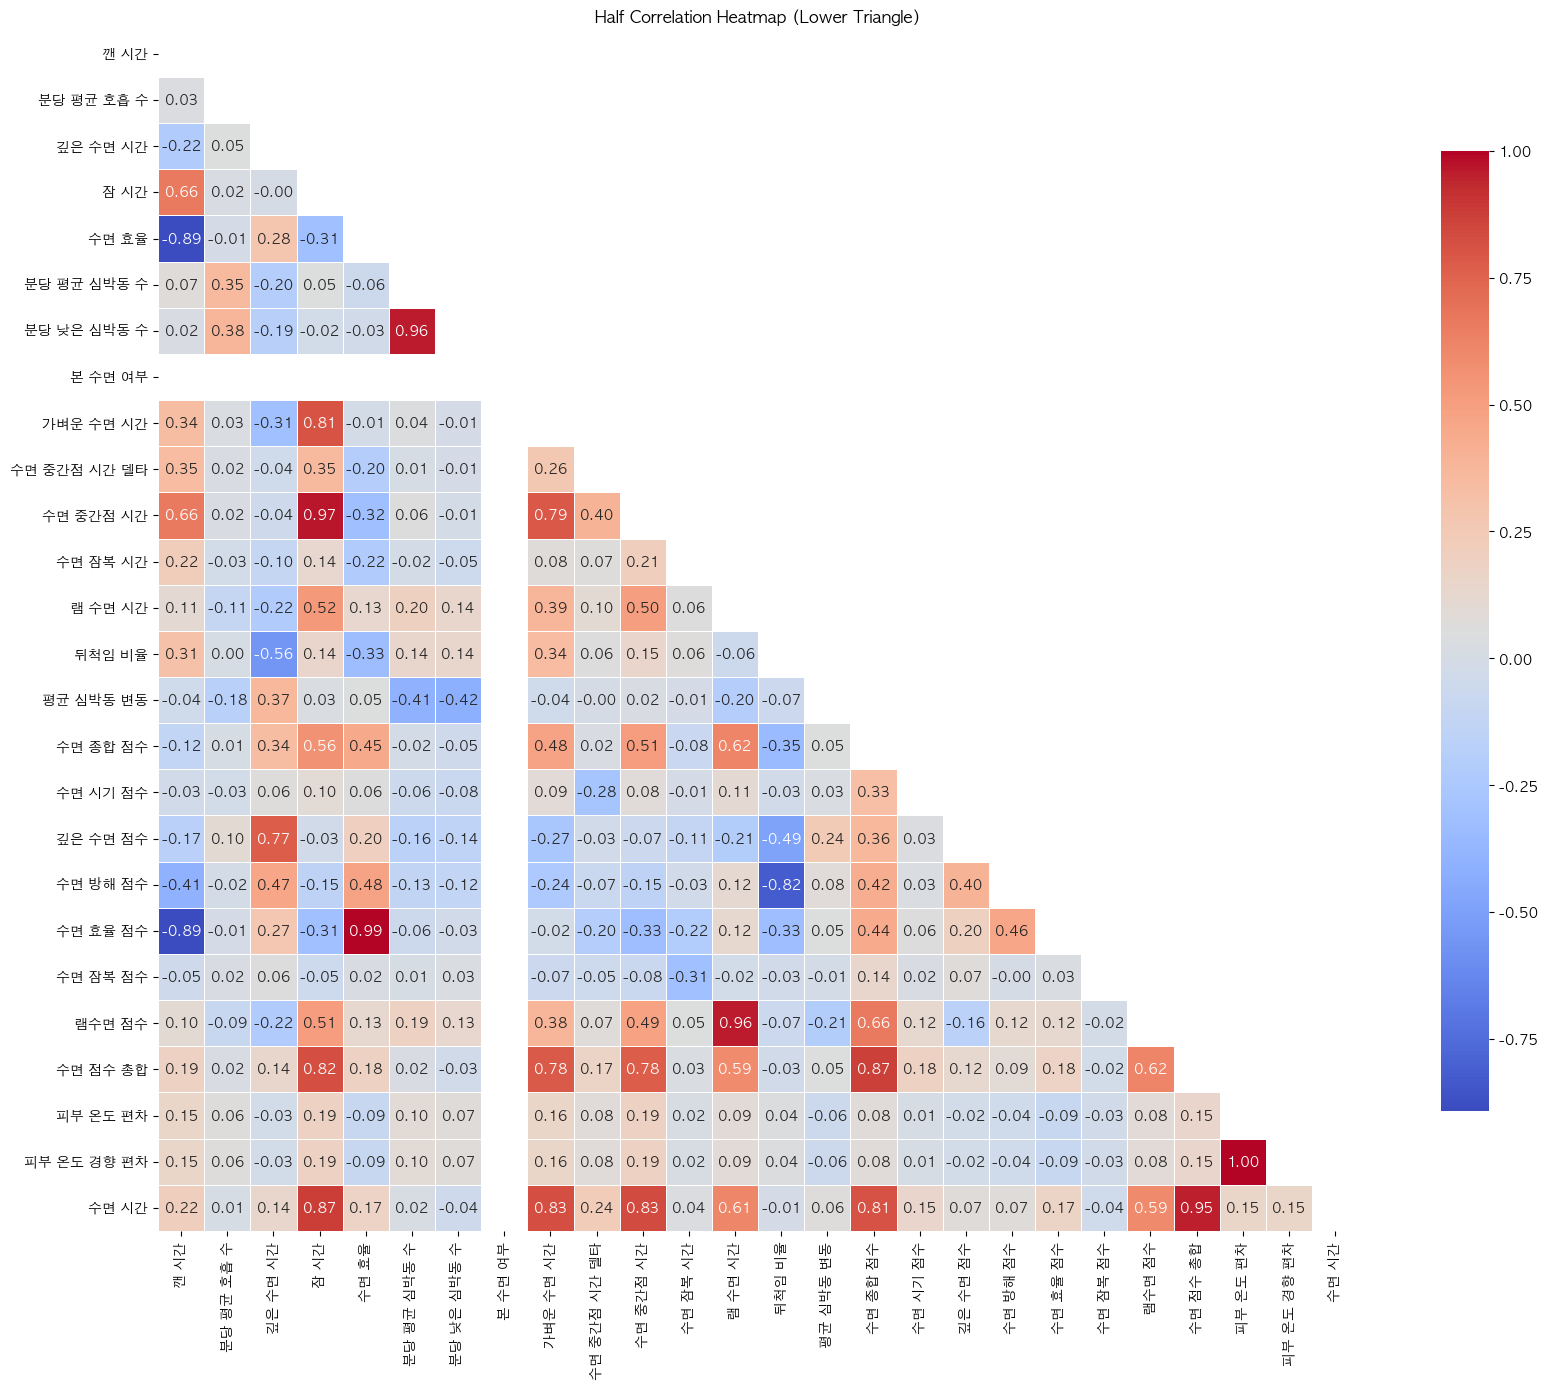

In [ ]:
corr_matrix = sleep_numeric.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  

# 히트맵 그리기
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=True, fmt=".2f", 
            annot_kws={"size": 10}, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Half Correlation Heatmap (Lower Triangle)")
plt.tight_layout()
plt.show()

In [52]:
from sklearn.preprocessing import StandardScaler

# Z-score 정규화
scaler = StandardScaler()
sleep_standardized = pd.DataFrame(scaler.fit_transform(sleep_numeric),
                                  columns=sleep_numeric.columns)

sleep_standardized.head(100)

,깬 시간,분당 평균 호흡 수,깊은 수면 시간,잠 시간,수면 효율,분당 평균 심박동 수,분당 낮은 심박동 수,본 수면 여부,가벼운 수면 시간,수면 중간점 시간 델타,...,수면 시기 점수,깊은 수면 점수,수면 방해 점수,수면 효율 점수,수면 잠복 점수,램수면 점수,수면 점수 총합,피부 온도 편차,피부 온도 경향 편차,수면 시간
0,0.909990,0.859195,1.924020,1.247166,-0.530038,-1.015133,-0.905475,0.0,0.119224,4.716583,...,-0.216290,0.740810,0.964468,-0.537928,0.629575,-0.007105,1.092995,0.031299,0.031299,1.036314
1,0.293464,0.955763,0.894351,-0.080514,-0.530038,-1.045234,-0.905475,0.0,-0.677905,-0.426478,...,0.504140,0.660463,0.885843,-0.537928,1.162712,-0.447335,-0.347008,1.107843,1.107843,-0.294696
2,1.439680,0.955763,-0.193166,0.402279,-1.671655,-1.156062,-1.208348,0.0,-0.555270,-0.266705,...,0.504140,0.499771,-0.450773,-1.781640,-0.303415,0.399262,-0.495974,-0.190342,-0.190342,-0.407017
3,-0.427263,0.569488,0.894351,-0.546063,0.269095,-1.284677,-1.359785,0.0,-1.304707,-0.350048,...,0.504140,0.660463,1.121717,0.291213,0.229722,0.568581,-0.495974,-0.411984,-0.411984,-0.435097
4,0.467133,0.859195,-0.308859,-1.227146,-1.899979,-1.321619,-1.208348,0.0,-1.665800,-0.861883,...,-0.604213,0.258733,0.492721,-1.885283,-0.103489,-1.056885,-2.134598,-1.551853,-1.551853,-1.900892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.189263,-0.879042,-0.019626,0.540220,-0.073390,-1.190268,-1.208348,0.0,0.786904,0.086830,...,-0.382543,0.539944,-0.686646,-0.071537,-0.103489,-0.142560,0.596442,1.139506,1.139506,0.581412
96,-0.774601,-0.975611,-0.355136,0.203989,1.068228,-1.428342,-1.208348,0.0,1.563594,-0.132025,...,0.504140,0.138213,-0.529397,1.068532,-0.503341,-0.955293,0.795063,0.316267,0.316267,0.766742
97,-0.158076,-0.203061,0.489424,0.505735,0.383257,-1.249102,-1.208348,0.0,1.147997,0.052008,...,-0.105454,0.620290,-0.843895,0.394855,-0.836552,-1.158476,0.795063,0.632897,0.632897,0.761126
98,-0.557515,-0.492768,-0.760063,-0.839187,0.269095,-1.403714,-1.056912,0.0,0.091972,0.423018,...,-2.765503,-0.705421,-0.843895,0.394855,-0.836552,-1.192340,-0.843561,-1.013582,-1.013582,-0.732749


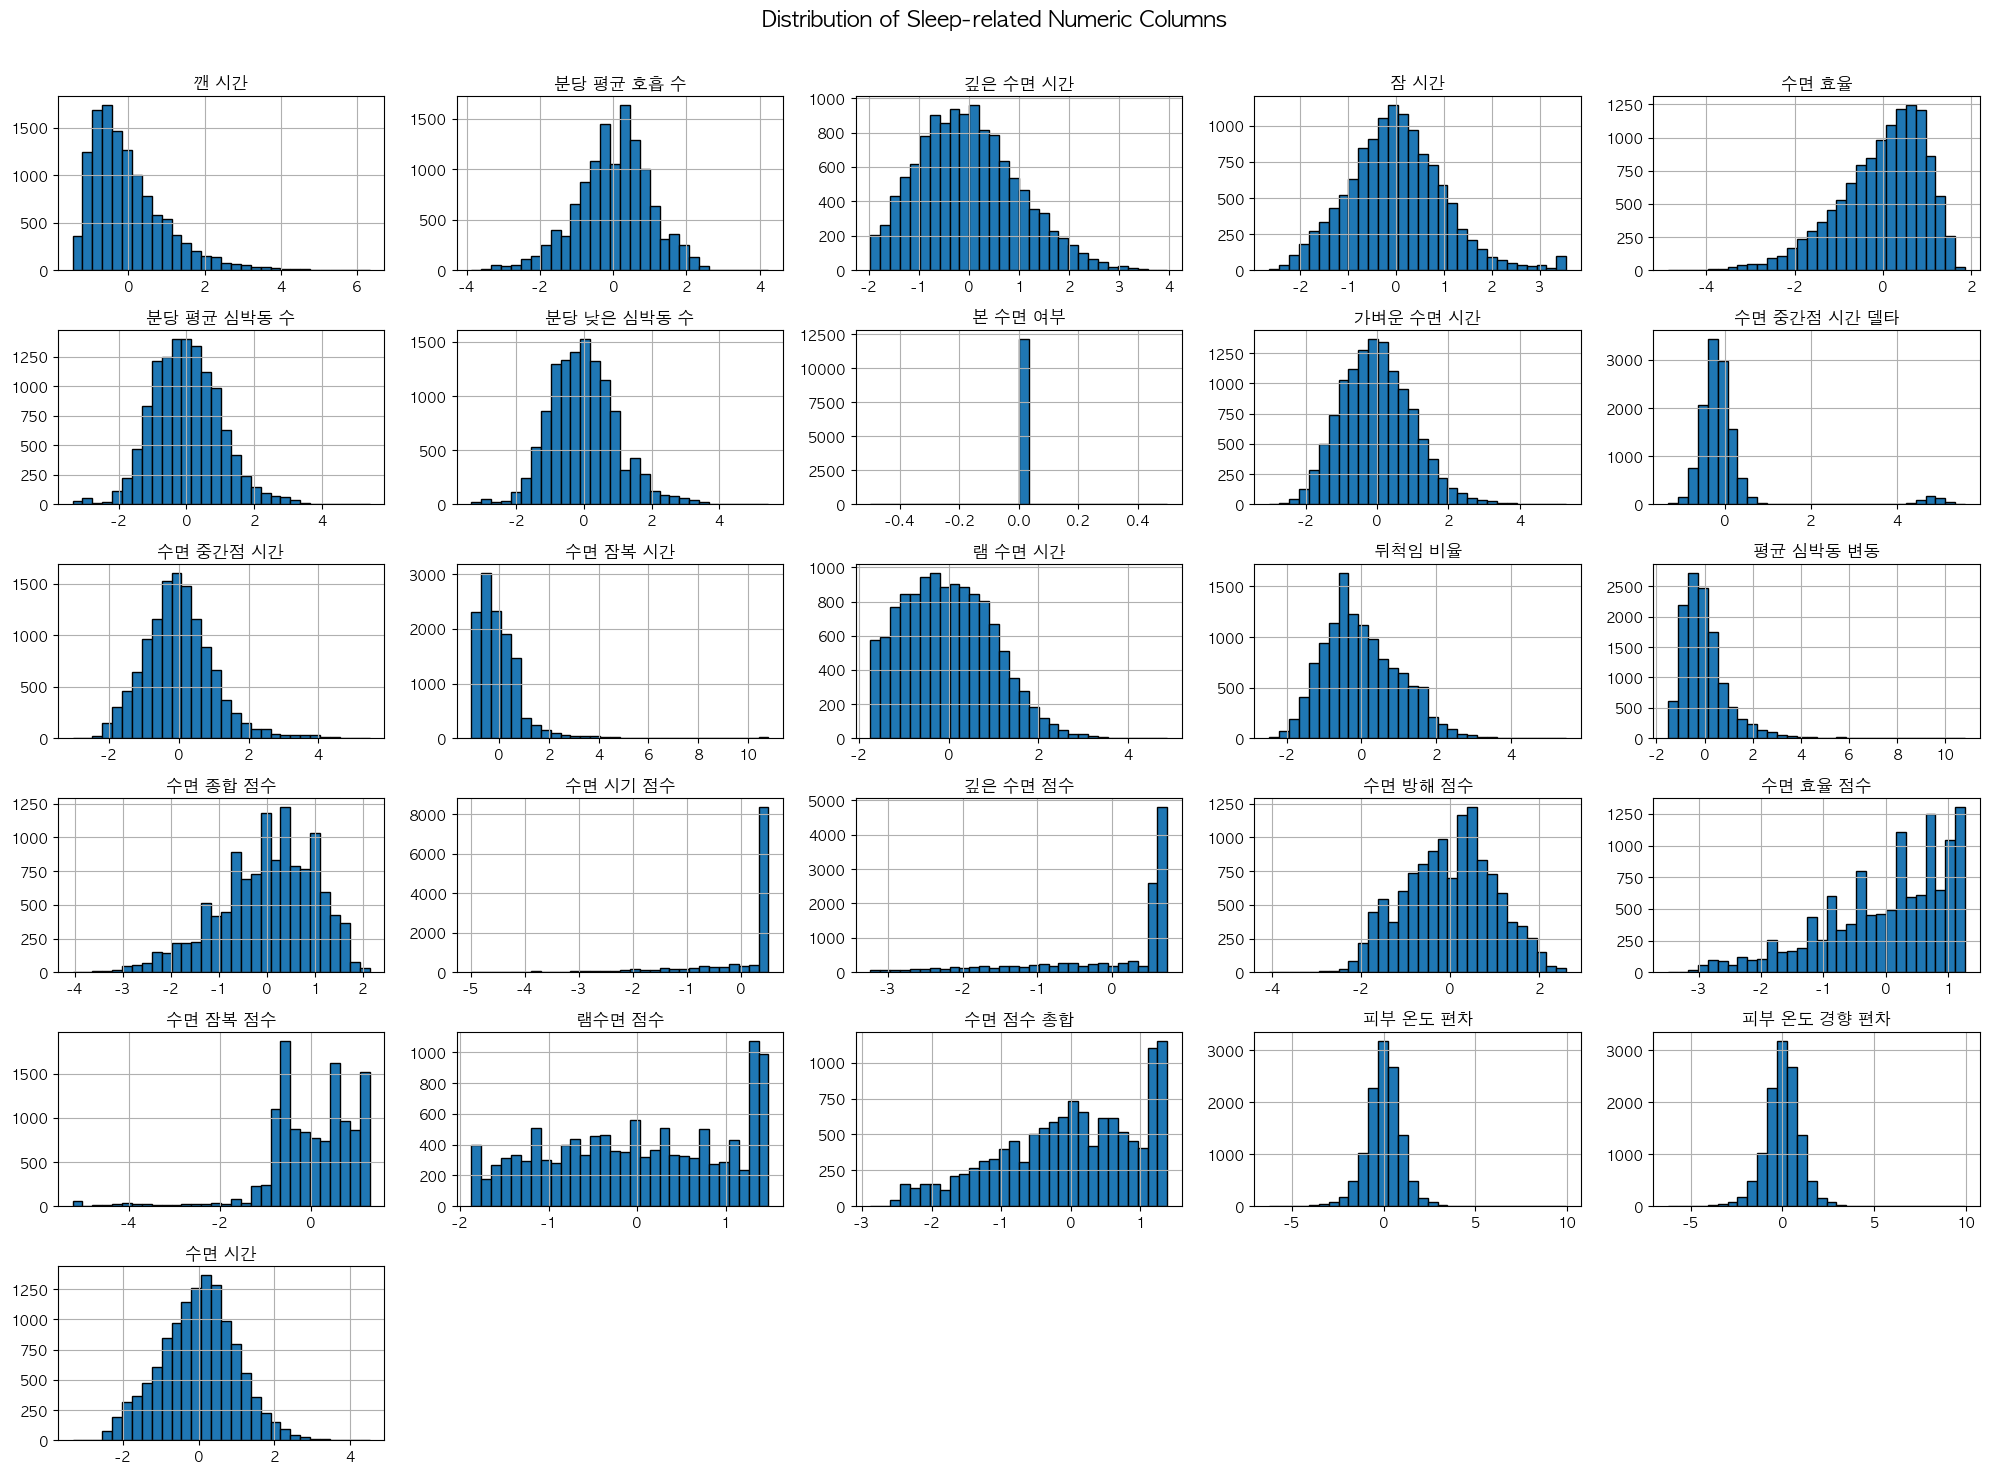

In [53]:
sleep_standardized.hist(figsize=(20, 15), bins=30, grid=True, edgecolor='black')
plt.suptitle("Distribution of Sleep-related Numeric Columns", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

----평균치 비교----

/var/folders/qz/npk7yn0126qdt7_l59knvtvh0000gn/T/ipykernel_8826/860667405.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/qz/npk7yn0126qdt7_l59knvtvh0000gn/T/ipykernel_8826/860667405.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/qz/npk7yn0126qdt7_l59knvtvh0000gn/T/ipykernel_8826/860667405.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/qz/npk7yn0126qdt7_l59knvtvh0000gn/T/ipykernel_8826/860667405.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

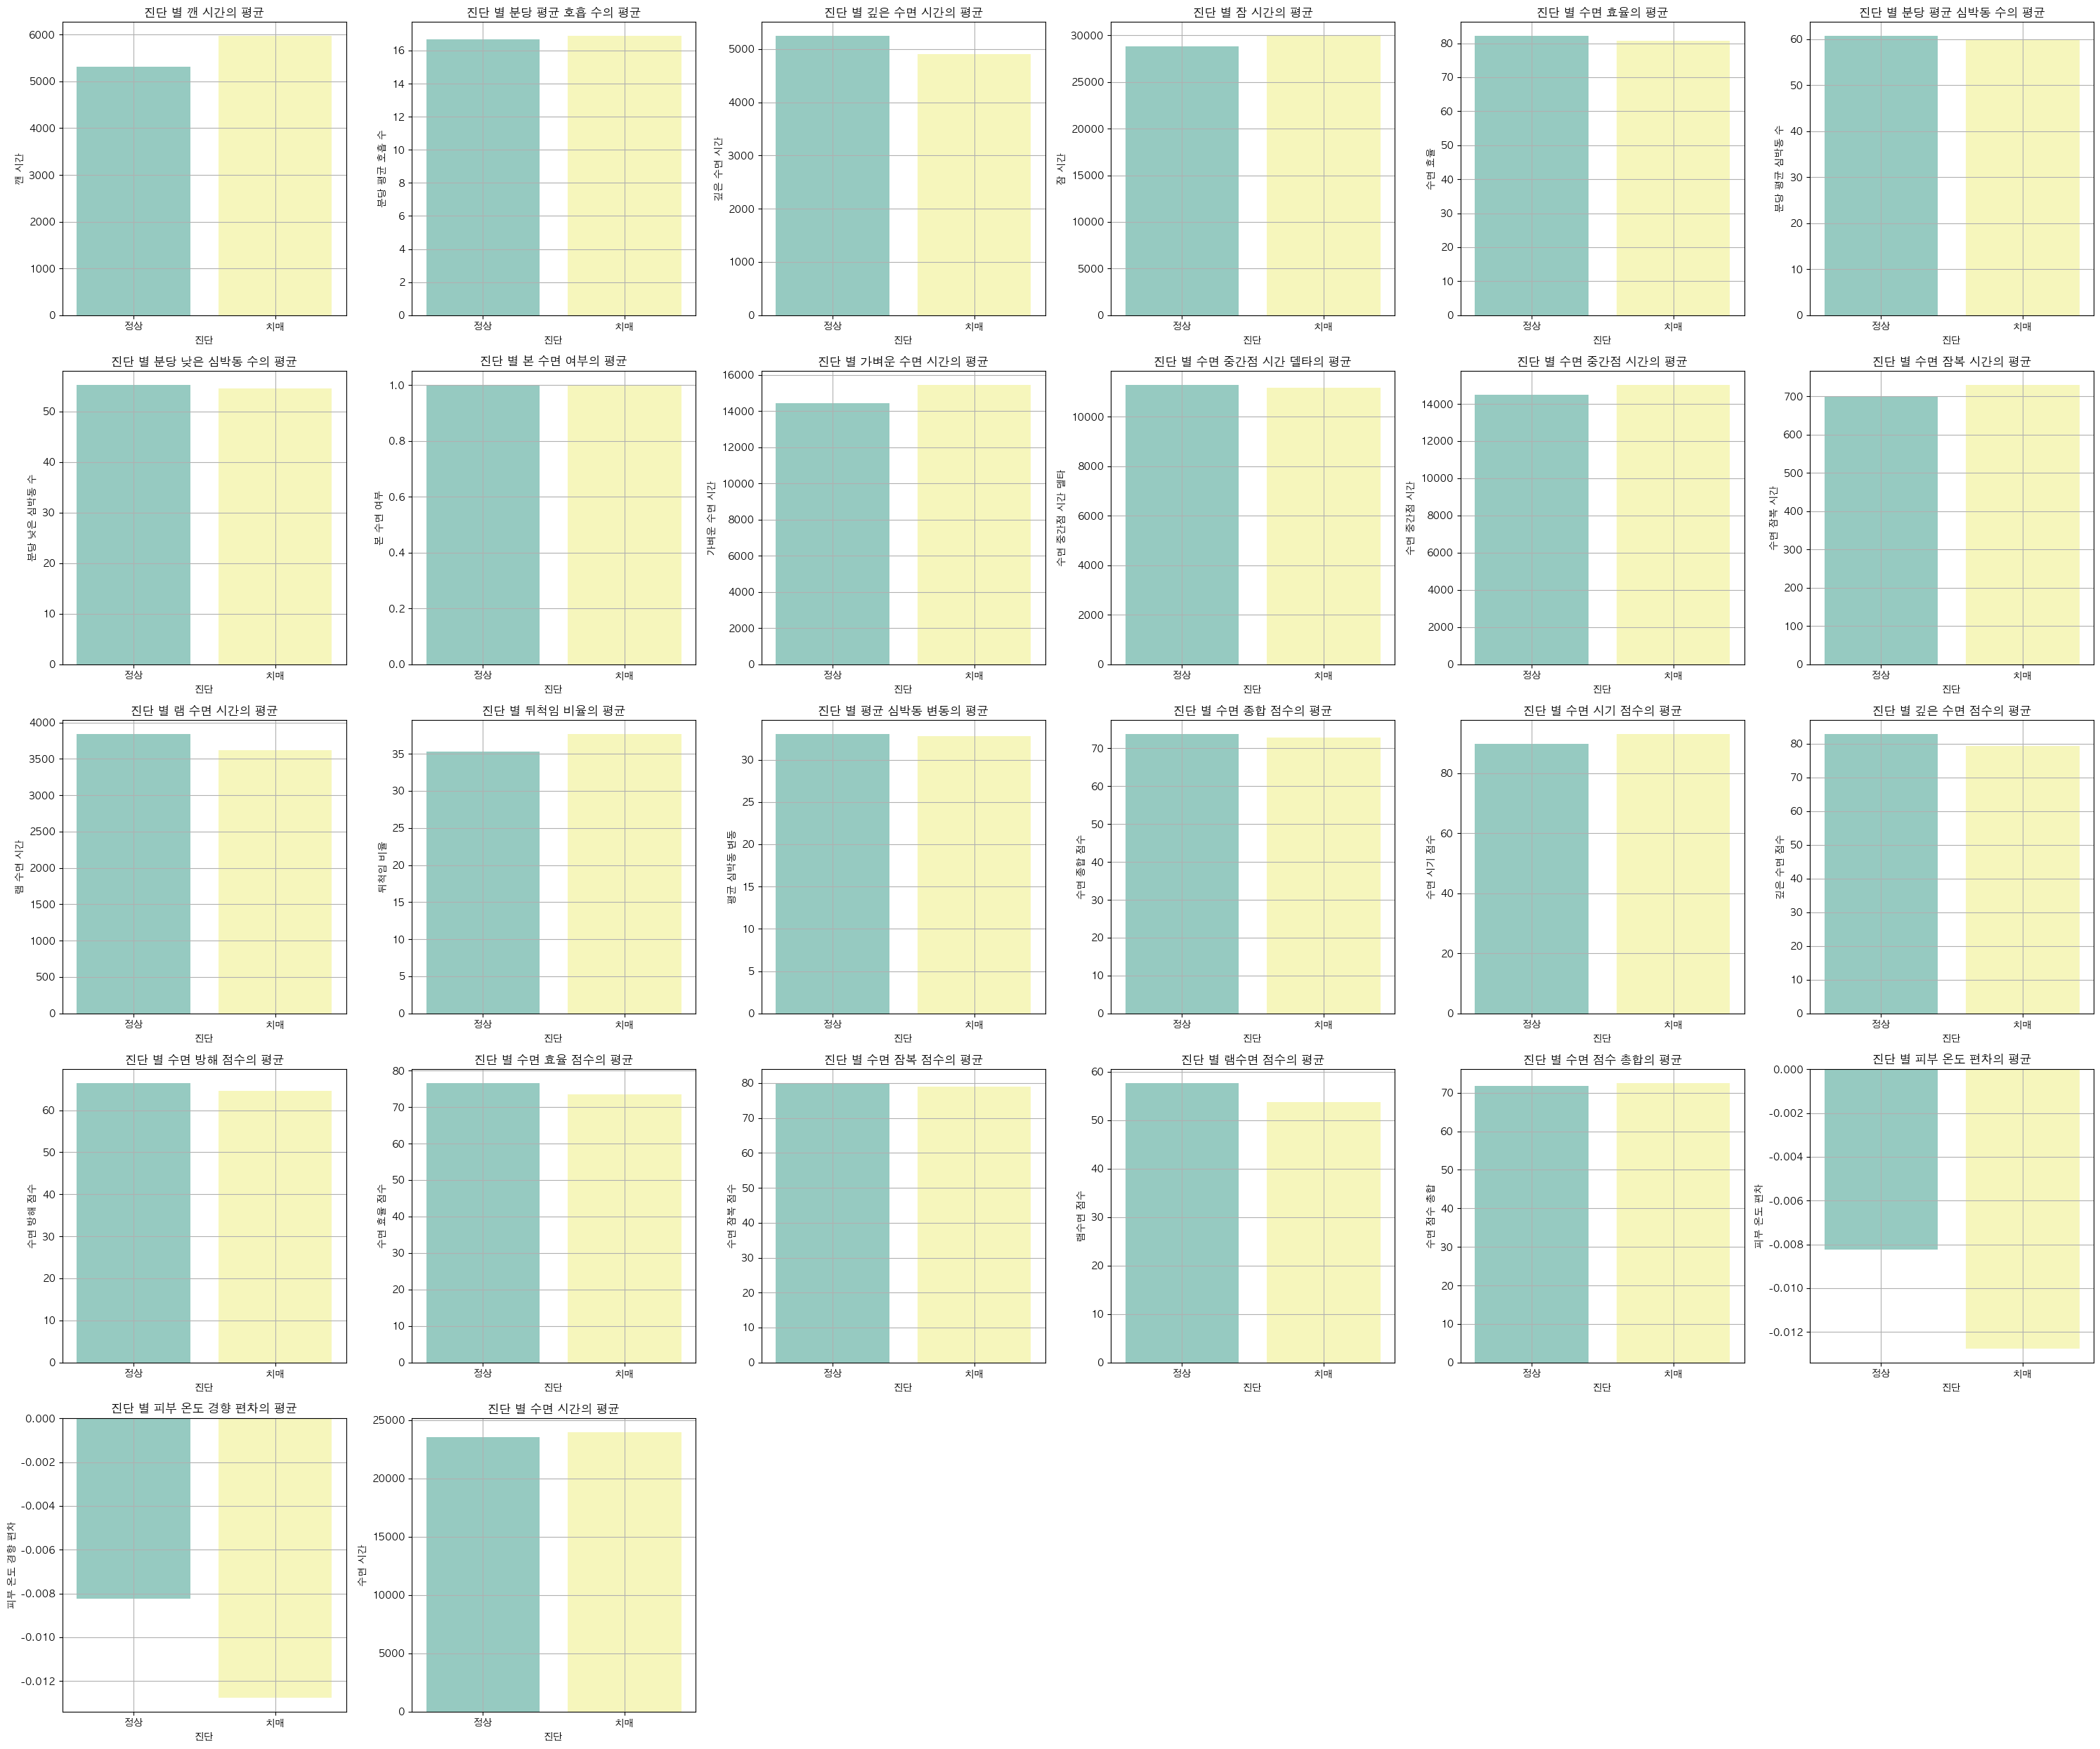

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 수치형 컬럼 개수
numeric_cols = sleep.select_dtypes(include='number').columns
n = len(numeric_cols)

# 서브플롯 배치 계산
cols = math.ceil(math.sqrt(n))
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*5))
axes = axes.flatten()

# 각 수치형 변수별로 본 수면 여부에 따른 평균 시각화
for i, col in enumerate(numeric_cols):
    sleep_mean = sleep.groupby('진단')[col].mean()
    
    sns.barplot(
        x=sleep_mean.index,
        y=sleep_mean.values,   # ✅ 수정된 부분
        palette='Set3',
        ax=axes[i]
    )
    axes[i].set_title(f'진단 별 {col}의 평균')
    axes[i].set_xlabel("진단")
    axes[i].set_ylabel(f'{col}')
    axes[i].grid(True)

# 남은 subplot 비우기
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


--------

In [55]:
pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [56]:
import statsmodels.api as sm
cols = ["깬 시간","램 수면 시간","뒤척임 비율"]
sleep_reg = sleep[cols].dropna()

x1 = sm.add_constant(sleep_reg["깬 시간"])
y1 = sleep_reg["램 수면 시간"]
model1 = sm.OLS(y1,x1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                램 수면 시간   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     139.8
Date:                Wed, 18 Jun 2025   Prob (F-statistic):           4.38e-32
Time:                        14:52:46   Log-Likelihood:            -1.1075e+05
No. Observations:               12183   AIC:                         2.215e+05
Df Residuals:                   12181   BIC:                         2.215e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3388.5099     36.826     92.013      0.0

In [57]:
import statsmodels.api as sm
cols = ["깬 시간","램 수면 시간","뒤척임 비율"]
sleep_reg = sleep[cols].dropna()

x2 = sm.add_constant(sleep_reg["깬 시간"])
y2 = sleep_reg["뒤척임 비율"]
model2 = sm.OLS(y2,x2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 뒤척임 비율   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     1272.
Date:                Wed, 18 Jun 2025   Prob (F-statistic):          3.96e-265
Time:                        14:52:46   Log-Likelihood:                -46794.
No. Observations:               12183   AIC:                         9.359e+04
Df Residuals:                   12181   BIC:                         9.361e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         30.3173      0.193    156.804      0.0

In [58]:
cols = ["뒤척임 비율","피부 온도 편차"]
sleep_reg = sleep[cols].dropna()

x2 = sm.add_constant(sleep_reg["피부 온도 편차"])
y2 = sleep_reg["뒤척임 비율"]
model2 = sm.OLS(y2,x2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 뒤척임 비율   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     20.68
Date:                Wed, 18 Jun 2025   Prob (F-statistic):           5.48e-06
Time:                        14:52:46   Log-Likelihood:                -47389.
No. Observations:               12183   AIC:                         9.478e+04
Df Residuals:                   12181   BIC:                         9.480e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.1891      0.107    337.407      0.0

------------------------------------

In [59]:
dem = sleep[sleep["진단"] == "치매"]
dem.head(1)

,이메일,깬 시간,잠 종료 시간,잠 시작 시간,분당 평균 호흡 수,깊은 수면 시간,잠 시간,수면 효율,5분 당 심박동 로그,분당 평균 심박동 수,...,깊은 수면 점수,수면 방해 점수,수면 효율 점수,수면 잠복 점수,램수면 점수,수면 점수 총합,피부 온도 편차,피부 온도 경향 편차,수면 시간,진단
0,nia+279@rowan.kr,8700,2020-10-19 05:10:28,2020-10-18 18:38:28,17.875,10110,37920,77,"[63.0, 61.0, 59.0, 58.0, 58.0, 58.0, 56.0, 55....",53.04,...,100,78,65,89,56,94,0.0,0.0,29220,치매


In [60]:
nom = sleep[sleep["진단"] == "정상"]
nom.head(1)

,이메일,깬 시간,잠 종료 시간,잠 시작 시간,분당 평균 호흡 수,깊은 수면 시간,잠 시간,수면 효율,5분 당 심박동 로그,분당 평균 심박동 수,...,깊은 수면 점수,수면 방해 점수,수면 효율 점수,수면 잠복 점수,램수면 점수,수면 점수 총합,피부 온도 편차,피부 온도 경향 편차,수면 시간,진단
64,nia+354@rowan.kr,8520,2020-10-30 07:29:20,2020-10-30 01:14:20,14.875,3600,22500,62,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",48.25,...,73,44,30,19,8,31,-0.32,-0.32,13980,정상


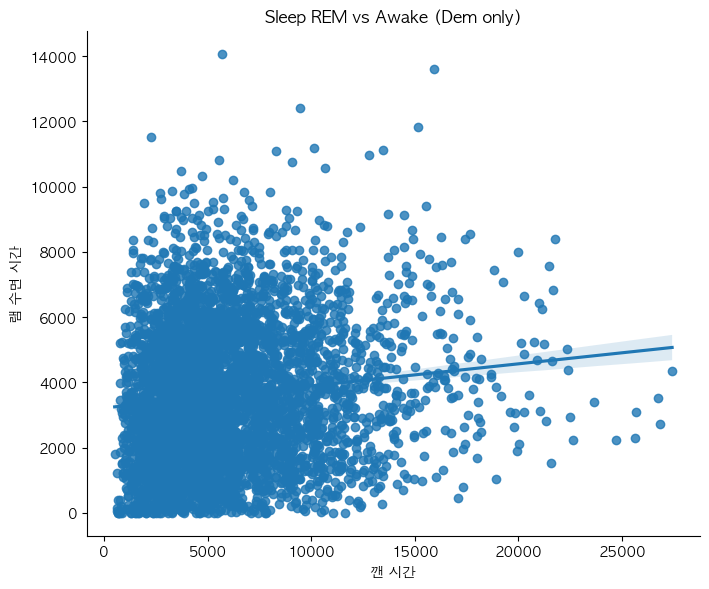

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 'Dem' 대상자만 필터링
dem_df = sleep[sleep["진단"] == "치매"]

# 2. 산점도 + 회귀선 시각화
sns.lmplot(data=dem_df, x="깬 시간", y="램 수면 시간", height=6, aspect=1.2)
plt.title("Sleep REM vs Awake (Dem only)")
plt.xlabel("깬 시간")
plt.ylabel("램 수면 시간")
plt.tight_layout()
plt.show()

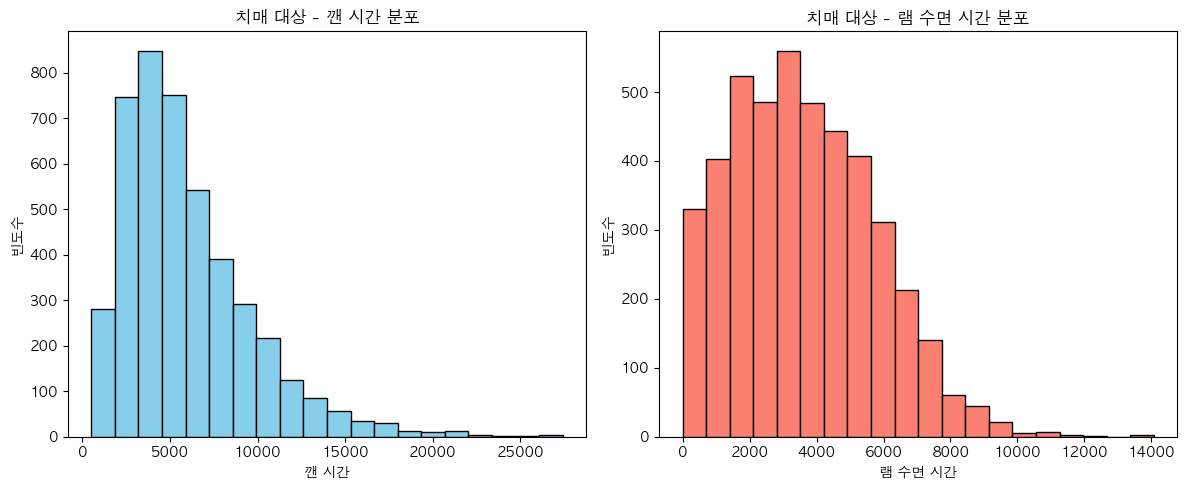

In [62]:
plt.figure(figsize=(12, 5))

# 1. 깬 시간
plt.subplot(1, 2, 1)
plt.hist(dem_df["깬 시간"].dropna(), bins=20, color="skyblue", edgecolor="black")
plt.title("치매 대상 - 깬 시간 분포")
plt.xlabel("깬 시간")
plt.ylabel("빈도수")

# 2. 램 수면 시간
plt.subplot(1, 2, 2)
plt.hist(dem_df["램 수면 시간"].dropna(), bins=20, color="salmon", edgecolor="black")
plt.title("치매 대상 - 램 수면 시간 분포")
plt.xlabel("램 수면 시간")
plt.ylabel("빈도수")

plt.tight_layout()
plt.show()

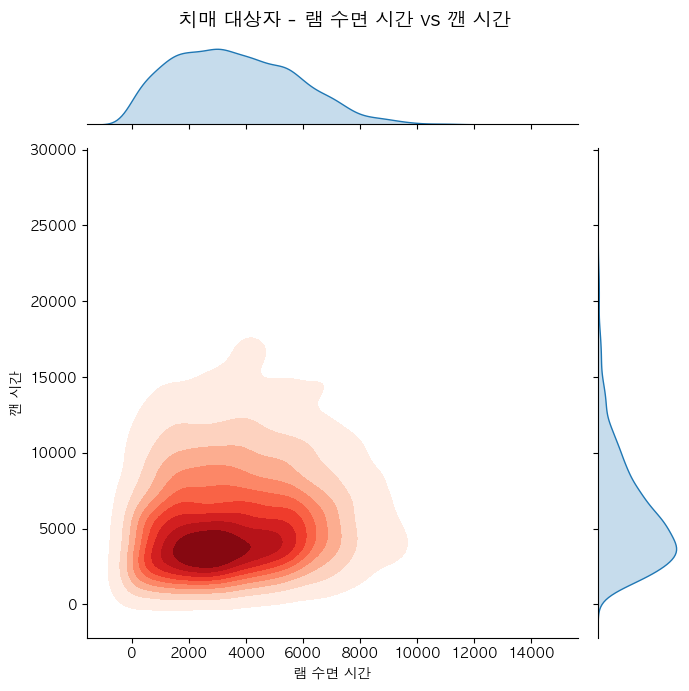

In [63]:
# 1. 치매 대상 필터링
dem_df = sleep[sleep["진단"] == "치매"]

# 2. KDE jointplot 시각화
sns.jointplot(
    data=dem_df,
    x="램 수면 시간",
    y="깬 시간",
    kind="kde",
    fill=True,
    cmap="Reds",
    height=7
)

plt.suptitle("치매 대상자 - 램 수면 시간 vs 깬 시간", fontsize=14)
plt.tight_layout()
plt.show()

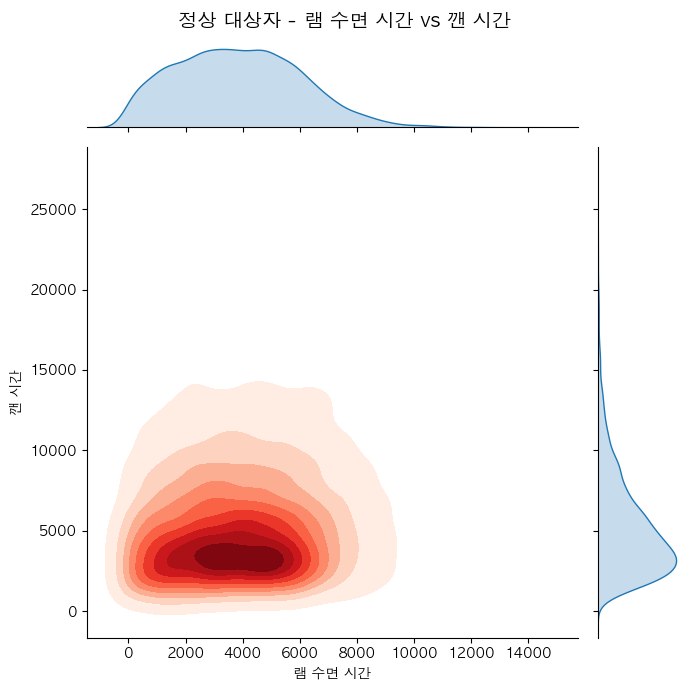

In [64]:
# 1. 정상 대상 필터링
dem_df = sleep[sleep["진단"] == "정상"]

# 2. KDE jointplot 시각화
sns.jointplot(
    data=dem_df,
    x="램 수면 시간",
    y="깬 시간",
    kind="kde",
    fill=True,
    cmap="Reds",
    height=7
)

plt.suptitle("정상 대상자 - 램 수면 시간 vs 깬 시간", fontsize=14)
plt.tight_layout()
plt.show()

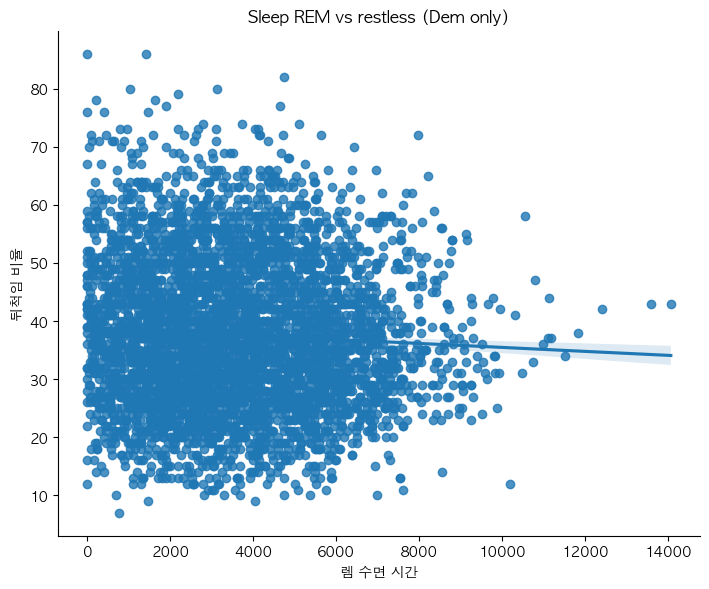

In [65]:
dem_df = sleep[sleep["진단"] == "치매"]

# 2. 산점도 + 회귀선 시각화
sns.lmplot(data=dem_df, x="램 수면 시간", y="뒤척임 비율", height=6, aspect=1.2)
plt.title("Sleep REM vs restless (Dem only)")
plt.xlabel("렘 수면 시간")
plt.ylabel("뒤척임 비율")
plt.tight_layout()
plt.show()

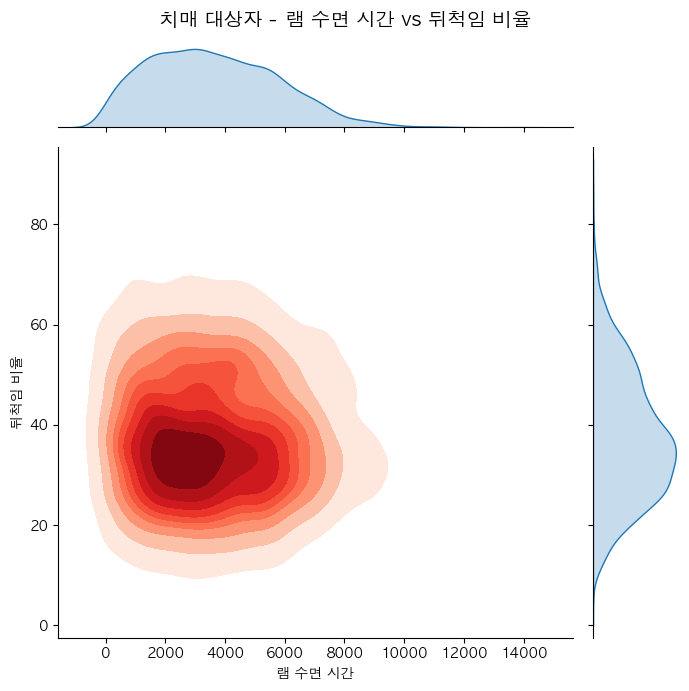

In [66]:
dem_df = sleep[sleep["진단"] == "치매"]

sns.jointplot(
    data=dem_df,
    x="램 수면 시간",
    y="뒤척임 비율",
    kind="kde",
    fill=True,
    cmap="Reds",
    height=7
)

plt.suptitle("치매 대상자 - 램 수면 시간 vs 뒤척임 비율", fontsize=14)
plt.tight_layout()
plt.show()


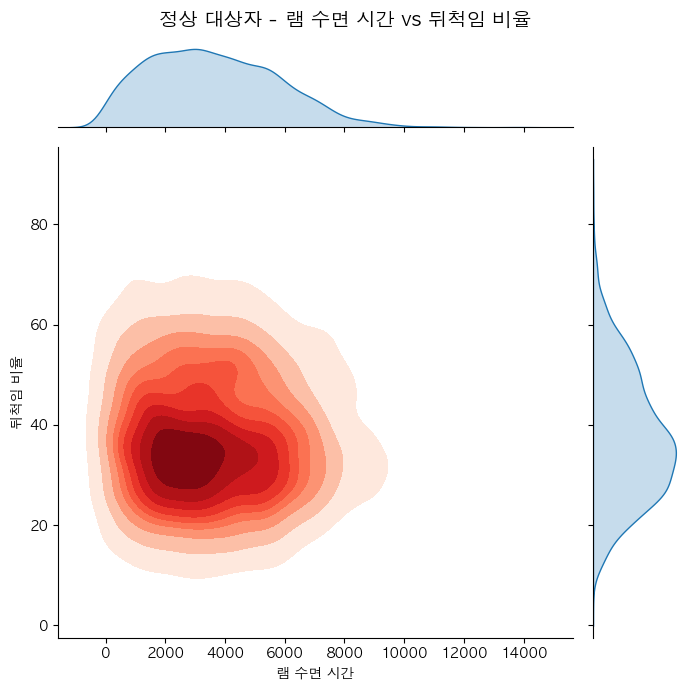

In [67]:
em_df = sleep[sleep["진단"] == "정상"]

sns.jointplot(
    data=dem_df,
    x="램 수면 시간",
    y="뒤척임 비율",
    kind="kde",
    fill=True,
    cmap="Reds",
    height=7
)

plt.suptitle("정상 대상자 - 램 수면 시간 vs 뒤척임 비율", fontsize=14)
plt.tight_layout()
plt.show()

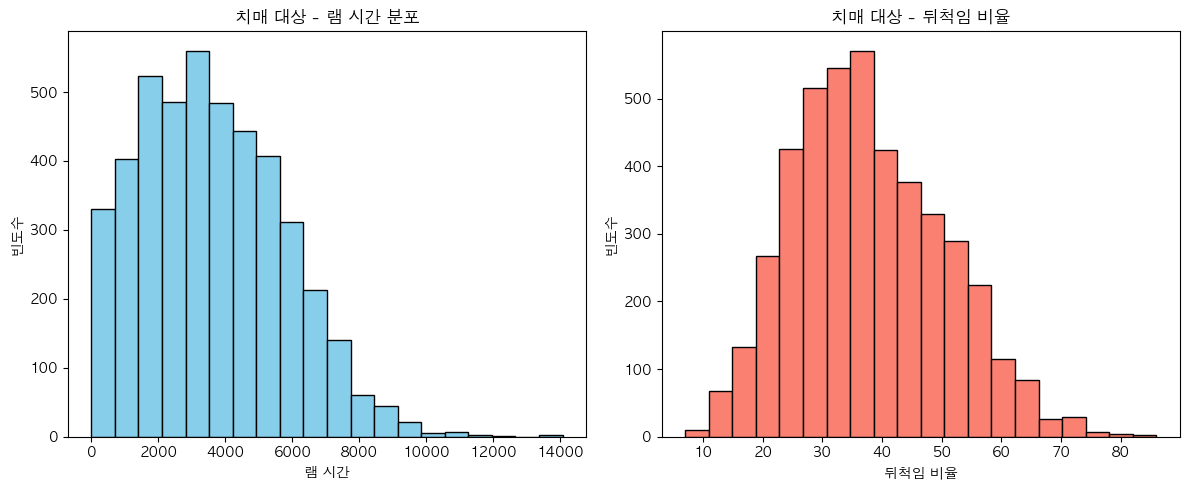

In [68]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(dem_df["램 수면 시간"].dropna(), bins=20, color="skyblue", edgecolor="black")
plt.title("치매 대상 - 램 시간 분포")
plt.xlabel("램 시간")
plt.ylabel("빈도수")

plt.subplot(1, 2, 2)
plt.hist(dem_df["뒤척임 비율"].dropna(), bins=20, color="salmon", edgecolor="black")
plt.title("치매 대상 - 뒤척임 비율")
plt.xlabel("뒤척임 비율")
plt.ylabel("빈도수")

plt.tight_layout()
plt.show()

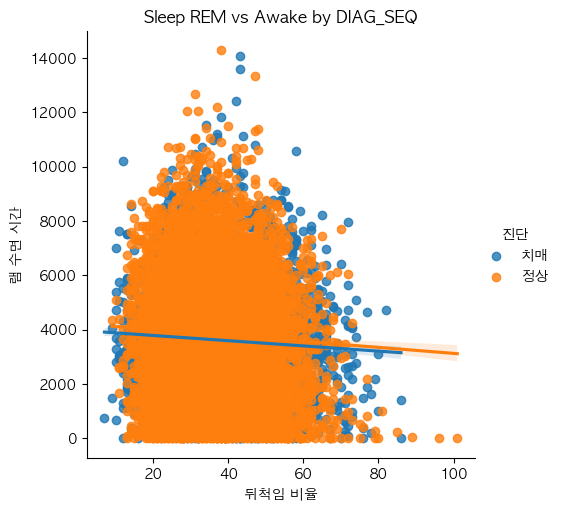

In [69]:
sleep_labeled = sleep
sns.lmplot(data=sleep, x="뒤척임 비율", y="램 수면 시간", hue="진단")
plt.title("Sleep REM vs Awake by DIAG_SEQ")
plt.show()


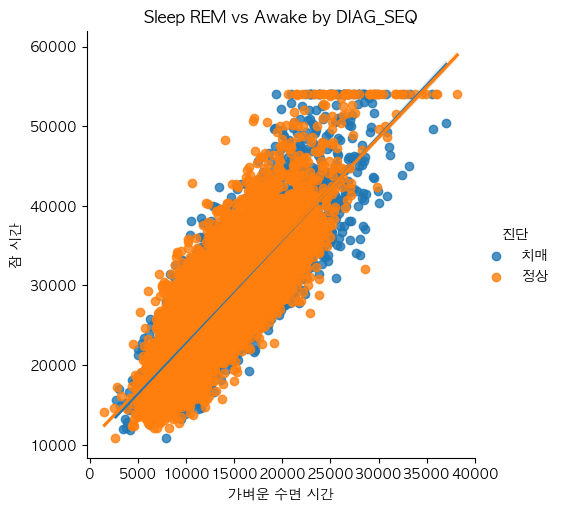

In [70]:
sleep_labeled = sleep
sns.lmplot(data=sleep, x="가벼운 수면 시간", y="잠 시간", hue="진단")
plt.title("Sleep REM vs Awake by DIAG_SEQ")
plt.show()

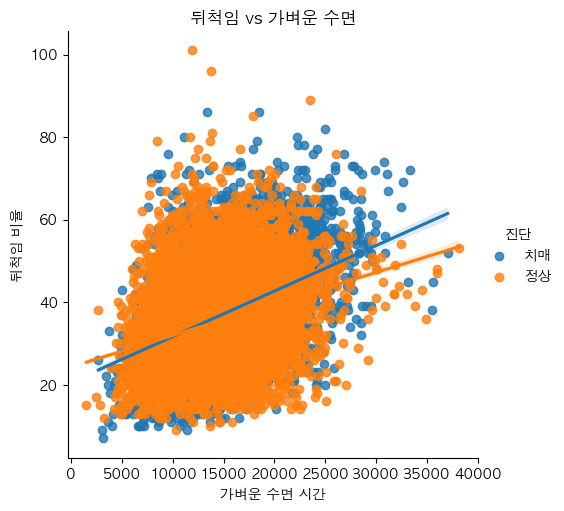

In [71]:
sleep_labeled = sleep
sns.lmplot(data=sleep, x="가벼운 수면 시간", y="뒤척임 비율", hue="진단")
plt.title("뒤척임 vs 가벼운 수면")
plt.show()

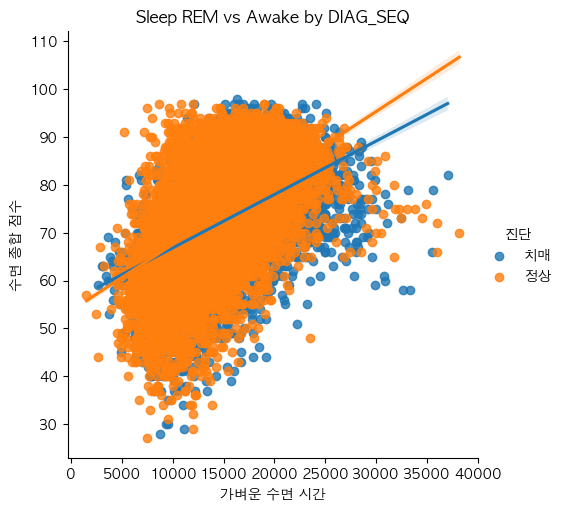

In [72]:
sleep_labeled = sleep
sns.lmplot(data=sleep, x="가벼운 수면 시간", y="수면 종합 점수", hue="진단")
plt.title("Sleep REM vs Awake by DIAG_SEQ")
plt.show()

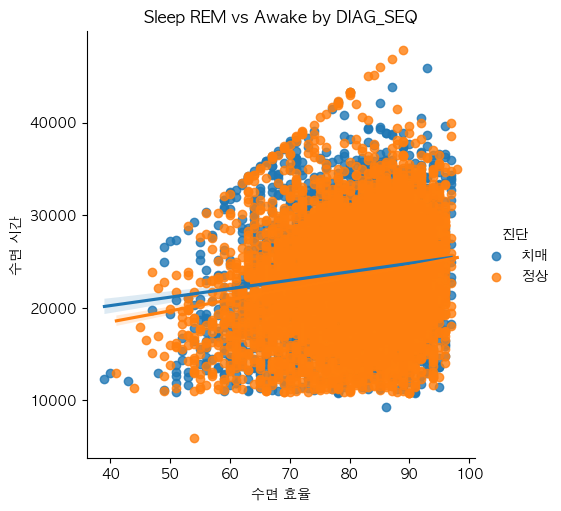

In [73]:
sleep_labeled = sleep
sns.lmplot(data=sleep, x="수면 효율", y="수면 시간", hue="진단")
plt.title("Sleep REM vs Awake by DIAG_SEQ")
plt.show()

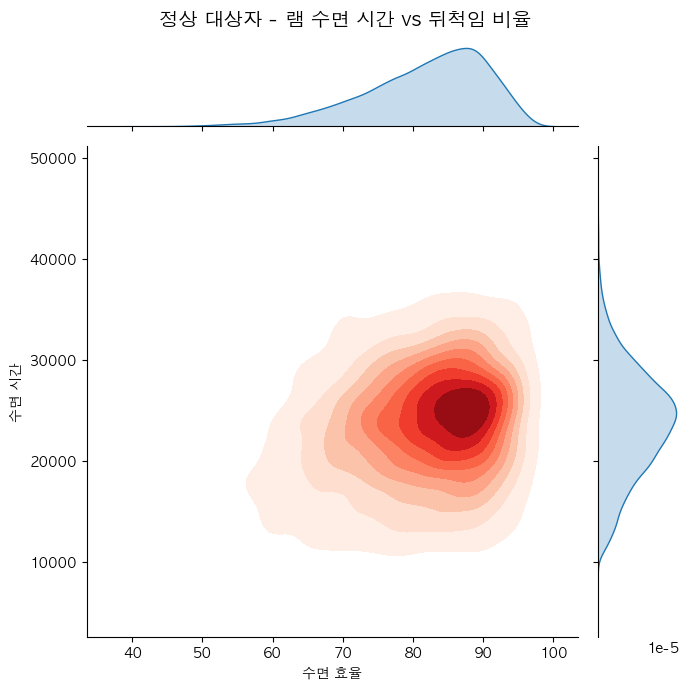

In [74]:
sns.jointplot(
    data=sleep,
    x="수면 효율",
    y="수면 시간",
    kind="kde",
    fill=True,
    cmap="Reds",
    height=7
)

plt.suptitle("정상 대상자 - 램 수면 시간 vs 뒤척임 비율", fontsize=14)
plt.tight_layout()
plt.show()

/Users/t2023-m0044/Library/Python/3.9/lib/python/site-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


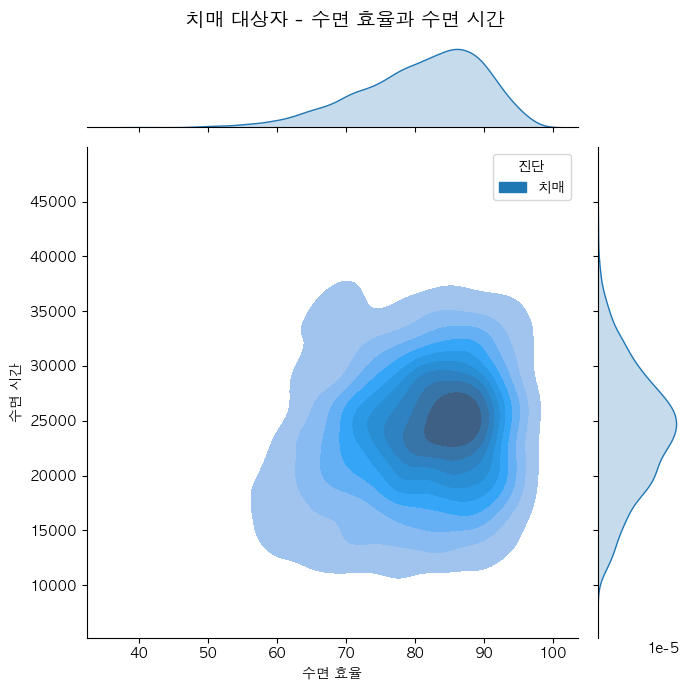

In [75]:
subset = sleep[sleep["진단"] == "치매"]

# 진단별 분할 jointplot
g = sns.jointplot(
    data=subset,
    x="수면 효율",
    y="수면 시간",
    hue="진단",              # ✅ 핵심: 그룹 컬러 구분
    kind="kde",              # kde or scatter
    fill=True,
    height=7,
    cmap="Reds"
)

plt.suptitle ("치매 대상자 - 수면 효율과 수면 시간", fontsize=14)
plt.tight_layout()
plt.show()

/Users/t2023-m0044/Library/Python/3.9/lib/python/site-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


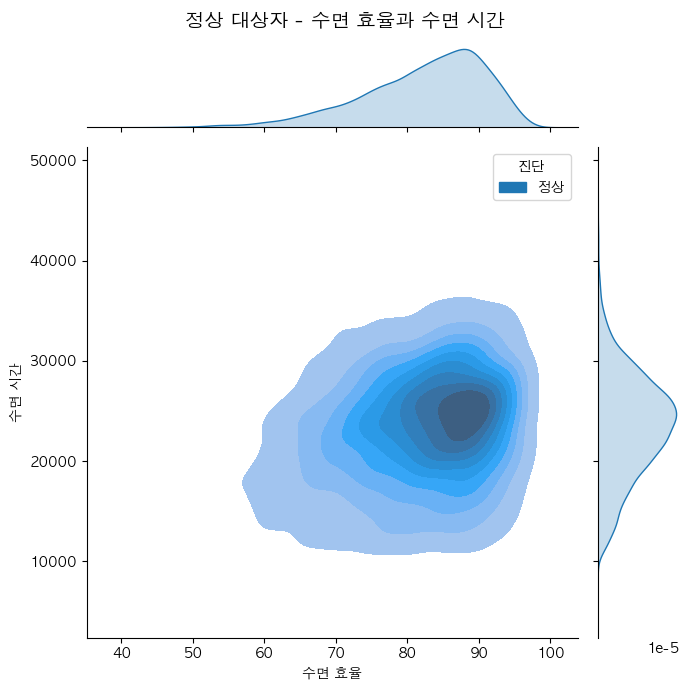

In [76]:
subset = sleep[sleep["진단"] == "정상"]

# 진단별 분할 jointplot
g = sns.jointplot(
    data=subset,
    x="수면 효율",
    y="수면 시간",
    hue="진단",              # ✅ 핵심: 그룹 컬러 구분
    kind="kde",              # kde or scatter
    fill=True,
    height=7,
    cmap="Reds"
)

plt.suptitle ("정상 대상자 - 수면 효율과 수면 시간", fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/qz/npk7yn0126qdt7_l59knvtvh0000gn/T/ipykernel_8826/1527845213.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="진단")


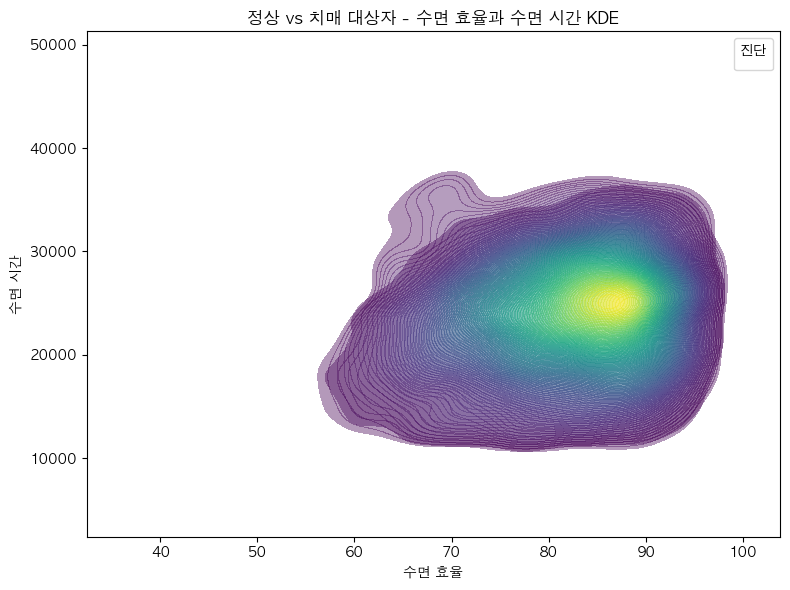

In [77]:
plt.figure(figsize=(8, 6))

for label, color in zip(["정상", "치매"], ["blue", "red"]):
    subset = sleep[sleep["진단"] == label]
    sns.kdeplot(
        x=subset["수면 효율"],
        y=subset["수면 시간"],
        fill=True,
        cmap=None,
        thresh=0.05,
        levels=100,
        label=label,
        alpha=0.4
    )

plt.title("정상 vs 치매 대상자 - 수면 효율과 수면 시간 KDE")
plt.xlabel("수면 효율")
plt.ylabel("수면 시간")
plt.legend(title="진단")
plt.tight_layout()
plt.show()


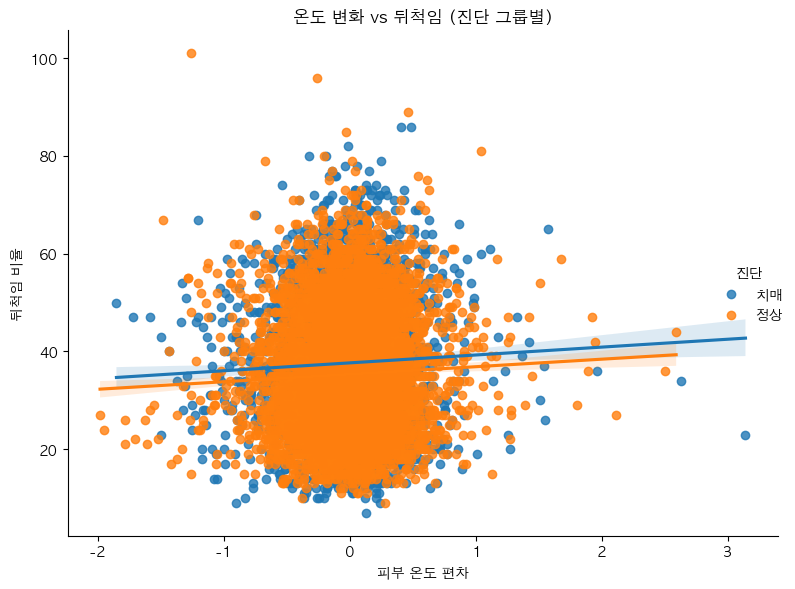

In [78]:
sns.lmplot(
    data=sleep,
    y="뒤척임 비율",
    x="피부 온도 편차",
    hue="진단",
    height=6,
    aspect=1.2
)
plt.title("온도 변화 vs 뒤척임 (진단 그룹별)")
plt.tight_layout()
plt.show()

/Users/t2023-m0044/Library/Python/3.9/lib/python/site-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


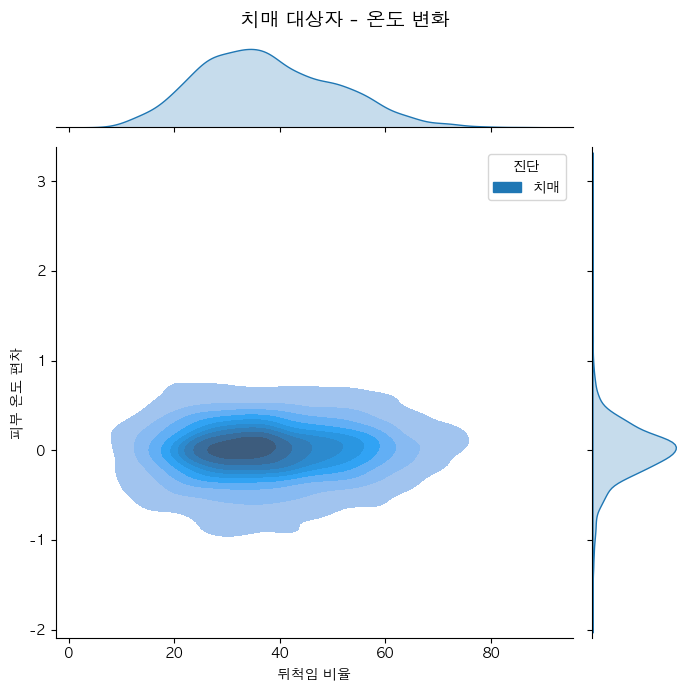

In [79]:
subset = sleep[sleep["진단"] == "치매"]

# 진단별 분할 jointplot
g = sns.jointplot(
    data=subset,
    x="뒤척임 비율",
    y="피부 온도 편차",
    hue="진단",              # ✅ 핵심: 그룹 컬러 구분
    kind="kde",              # kde or scatter
    fill=True,
    height=7,
    cmap="Reds"
)

plt.suptitle ("치매 대상자 - 온도 변화", fontsize=14)
plt.tight_layout()
plt.show()

/Users/t2023-m0044/Library/Python/3.9/lib/python/site-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


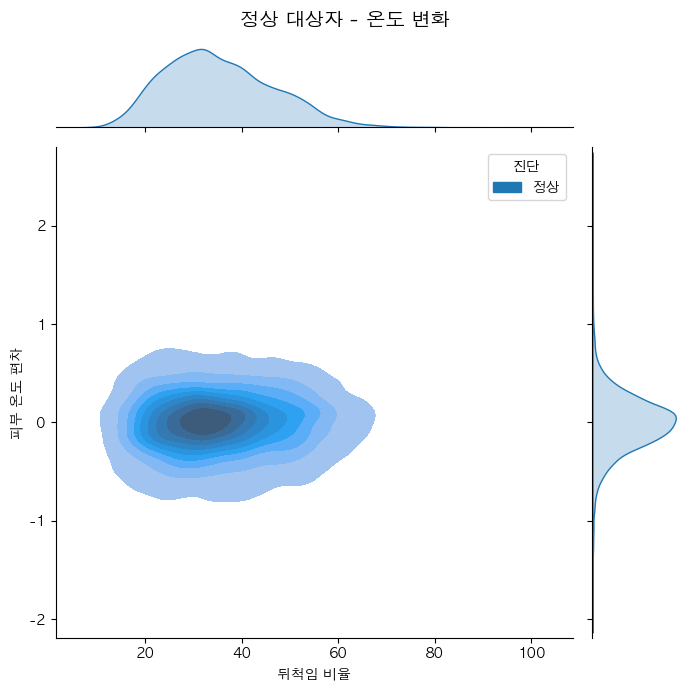

In [80]:
subset = sleep[sleep["진단"] == "정상"]

# 진단별 분할 jointplot
g = sns.jointplot(
    data=subset,
    x="뒤척임 비율",
    y="피부 온도 편차",
    hue="진단",              # ✅ 핵심: 그룹 컬러 구분
    kind="kde",              # kde or scatter
    fill=True,
    height=7,
    cmap="Reds"
)

plt.suptitle ("정상 대상자 - 온도 변화", fontsize=14)
plt.tight_layout()
plt.show()

In [81]:
# 결측치 제거 후 상관계수 계산
subset = sleep[["뒤척임 비율", "수면 방해 점수"]].dropna()
corr = subset["뒤척임 비율"].corr(subset["수면 방해 점수"])

print(f"뒤척임 비율과 수면 방해 점수 간의 상관계수: {corr:.3f}")

뒤척임 비율과 수면 방해 점수 간의 상관계수: -0.824


<Figure size 800x600 with 0 Axes>

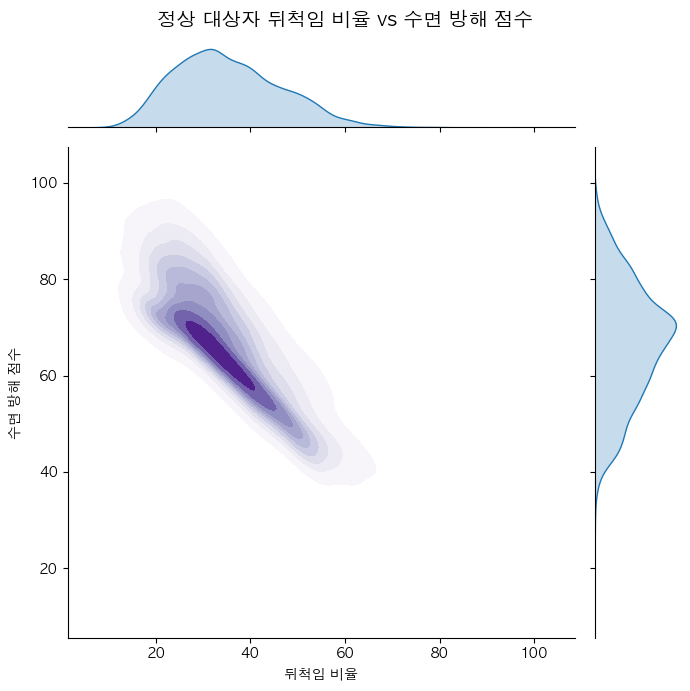

In [82]:
subset = sleep[sleep["진단"] == "정상"]
plt.figure(figsize=(8, 6))
sns.jointplot(
    data=subset,
    x="뒤척임 비율",
    y="수면 방해 점수",
    kind="kde",
    fill=True,
    cmap="Purples",
    height=7
)

plt.suptitle("정상 대상자 뒤척임 비율 vs 수면 방해 점수", fontsize=14)
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

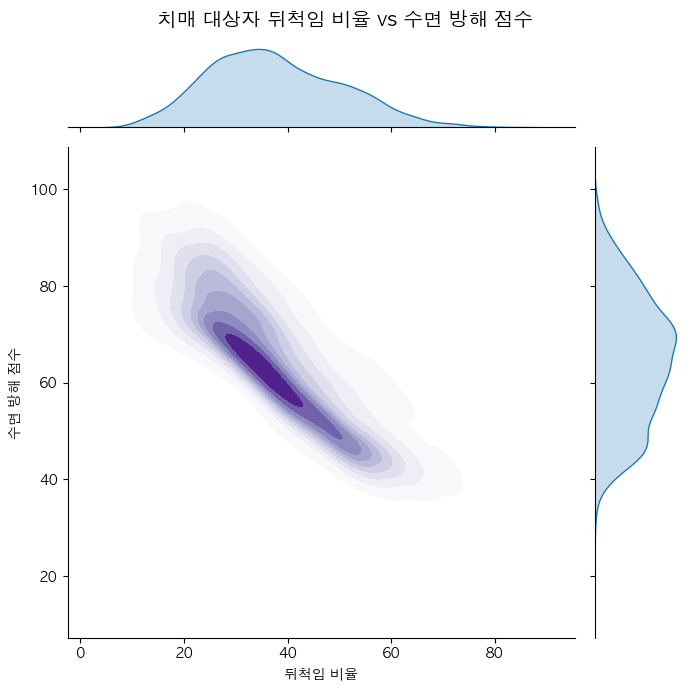

In [83]:
subset = sleep[sleep["진단"] == "치매"]
plt.figure(figsize=(8, 6))
sns.jointplot(
    data=subset,
    x="뒤척임 비율",
    y="수면 방해 점수",
    kind="kde",
    fill=True,
    cmap="Purples",
    height=7
)

plt.suptitle("치매 대상자 뒤척임 비율 vs 수면 방해 점수", fontsize=14)
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

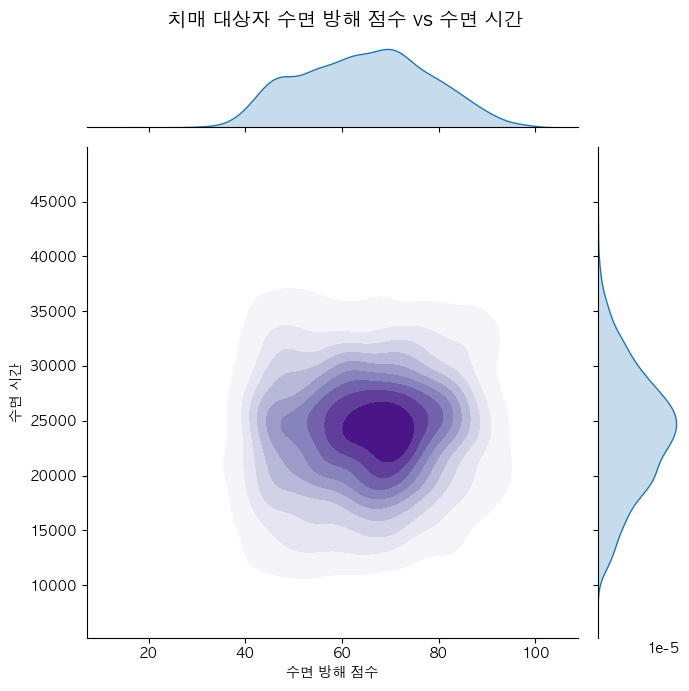

In [84]:
subset = sleep[sleep["진단"] == "치매"]
plt.figure(figsize=(8, 6))
sns.jointplot(
    data=subset,
    x="수면 방해 점수",
    y="수면 시간",
    kind="kde",
    fill=True,
    cmap="Purples",
    height=7
)

plt.suptitle("치매 대상자 수면 방해 점수 vs 수면 시간", fontsize=14)
plt.tight_layout()
plt.show()

In [85]:
# 필요한 컬럼만 추출하고 결측치 제거
subset = sleep[["수면 방해 점수", "수면 효율 점수"]].dropna()

# 상관계수 계산
corr = subset["수면 방해 점수"].corr(subset["수면 효율 점수"])
print(f"수면 방해 점수와 수면 효율 점수 간의 상관계수: {corr:.3f}")


수면 방해 점수와 수면 효율 점수 간의 상관계수: 0.465


<Figure size 800x600 with 0 Axes>

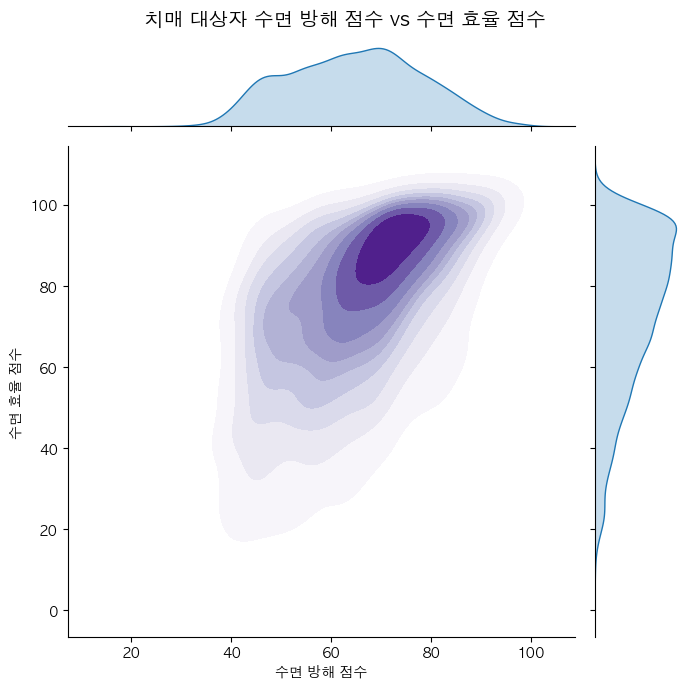

In [86]:
subset = sleep[sleep["진단"] == "치매"]
plt.figure(figsize=(8, 6))
sns.jointplot(
    data=subset,
    x="수면 방해 점수",
    y="수면 효율 점수",
    kind="kde",
    fill=True,
    cmap="Purples",
    height=7
)

plt.suptitle("치매 대상자 수면 방해 점수 vs 수면 효율 점수", fontsize=14)
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

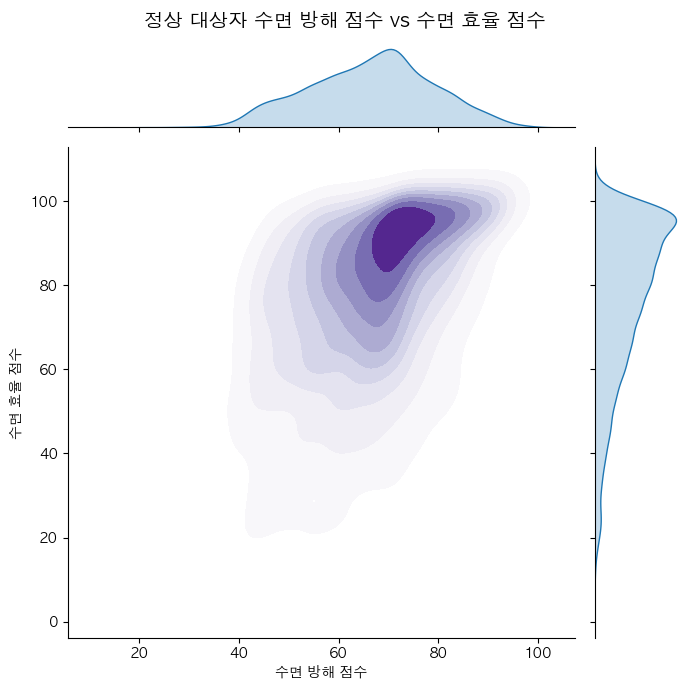

In [87]:
subset = sleep[sleep["진단"] == "정상"]
plt.figure(figsize=(8, 6))
sns.jointplot(
    data=subset,
    x="수면 방해 점수",
    y="수면 효율 점수",
    kind="kde",
    fill=True,
    cmap="Purples",
    height=7
)

plt.suptitle("정상 대상자 수면 방해 점수 vs 수면 효율 점수", fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/qz/npk7yn0126qdt7_l59knvtvh0000gn/T/ipykernel_8826/877322883.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=sleep_labeled, x="진단", y="수면 종합 점수", ci=None)


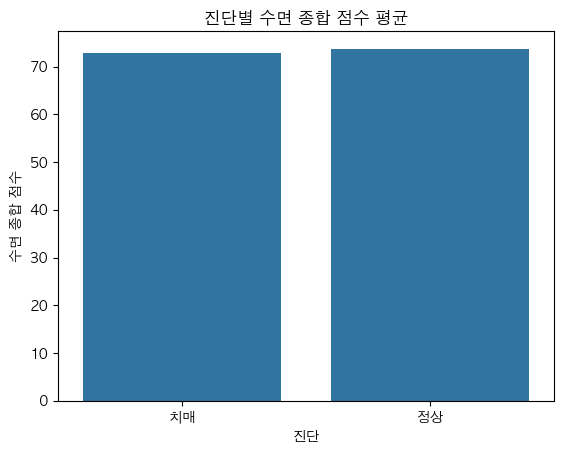

In [88]:
sns.barplot(data=sleep_labeled, x="진단", y="수면 종합 점수", ci=None)
plt.title("진단별 수면 종합 점수 평균")
plt.show()


/var/folders/qz/npk7yn0126qdt7_l59knvtvh0000gn/T/ipykernel_8826/1166522658.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=sleep_labeled, x="진단", y="깊은 수면 시간", ci=None)


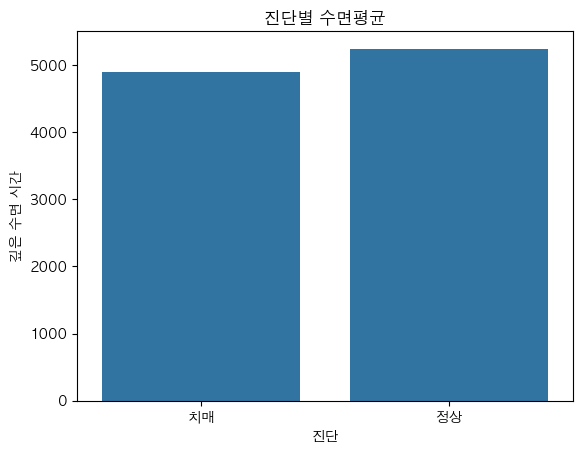

In [89]:
sns.barplot(data=sleep_labeled, x="진단", y="깊은 수면 시간", ci=None)
plt.title("진단별 수면평균")
plt.show()


In [90]:
sleep = sleep.copy()
sleep = sleep[(sleep["가벼운 수면 시간"] > 0) & (sleep["깊은 수면 시간"] > 0)]

sleep["깊은수면비율"] = sleep["깊은 수면 시간"] / (sleep["수면 시간"])


In [91]:
print(sleep.groupby("진단")["깊은수면비율"].mean().round(3))


진단
정상    0.231
치매    0.214
Name: 깊은수면비율, dtype: float64


In [92]:
sleep["가벼운 수면 비율"] = sleep["가벼운 수면 시간"] / (sleep["수면 시간"])
print(sleep.groupby("진단")["가벼운 수면 비율"].mean().round(3))

진단
정상    0.612
치매    0.641
Name: 가벼운 수면 비율, dtype: float64


In [93]:
print(sleep.groupby("진단")["램 수면 시간"].mean().round(3))

진단
정상    3837.408
치매    3616.397
Name: 램 수면 시간, dtype: float64


In [94]:
rr = sleep_labeled.copy()
rr = rr[
    (rr["수면 방해 점수"] > 0) & 
    (rr["램 수면 시간"] > 0)
]

rr["램수면_방해비율"] = rr["램 수면 시간"] / rr["수면 방해 점수"]
# 딩킹 필요 - 좀 설명력 필요

In [95]:
# 그룹별 평균
print(rr.groupby("진단")["램수면_방해비율"].mean().round(2))


진단
정상    59.73
치매    58.17
Name: 램수면_방해비율, dtype: float64


In [97]:

sleep["잠 시작 시간"] = pd.to_datetime(sleep["잠 시작 시간"])


sleep["월"] = sleep["잠 시작 시간"].dt.month

def get_season(month):
    if 3 <= month <= 8:
        return "여름"  
    else:
        return "겨울"  

sleep["계절"] = sleep["월"].apply(get_season)

In [ ]:
sleep.groupby("계절")["램 수면 시간"].mean()


계절
겨울    3758.295986
Name: 램 수면 시간, dtype: float64

In [98]:
sleep.count()

이메일              12165
깬 시간             12165
잠 종료 시간          12165
잠 시작 시간          12165
분당 평균 호흡 수       12165
깊은 수면 시간         12165
잠 시간             12165
수면 효율            12165
5분 당 심박동 로그      12165
분당 평균 심박동 수      12165
분당 낮은 심박동 수      12165
수면 상태 로그         12165
본 수면 여부          12165
가벼운 수면 시간        12165
수면 중간점 시간 델타     12165
수면 중간점 시간        12165
수면 잠복 시간         12165
램 수면 시간          12165
뒤척임 비율           12165
평균 심박동 변동        12165
5분당 심박동 변동 로그    12165
수면 종합 점수         12165
수면 시기 점수         12165
깊은 수면 점수         12165
수면 방해 점수         12165
수면 효율 점수         12165
수면 잠복 점수         12165
램수면 점수           12165
수면 점수 총합         12165
피부 온도 편차         12165
피부 온도 경향 편차      12165
수면 시간            12165
진단               12165
깊은수면비율           12165
가벼운 수면 비율        12165
월                12165
계절               12165
dtype: int64

-------------------------------------------------